In [1]:
import h5ify
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import get_data

from util import plot_multiple

%matplotlib inline

Compare my samples to the samples used by Stegmann

data will be saved to/loaded from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5
loading posteriors from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5


In [3]:
events = np.array(events)

In [4]:
weird_events = np.array([
    'GW190725_174728',
    'GW190727_060333',
    'GW190728_064510',
    'GW190731_140936',
    'GW190803_022701',
    'GW190805_211137',
    'GW190828_063405',
    'GW190828_065509',
    'GW190910_112807',
    'GW190915_235702',
    'GW190924_021846',
    'GW190925_232845',
    'GW190929_012149',
    'GW190930_133541',
])

weird_idxs = np.array([
    np.where(events == w)[0][0]
    for w in weird_events
])

nweird = len(weird_events)
assert len(weird_idxs) == nweird

In [8]:
events, posteriors, injections = get_data(
    snr_thresh=10,
    far_thresh=1,
    prefer_xphm=False,
    prefer_xphm_gwtc3=True
)

print(posteriors['mass_1'].shape)

if 'log_prior' in posteriors:
        posteriors['prior'] = np.exp(posteriors['log_prior'])
if 'log_prior' in injections:
    injections['prior'] = np.exp(injections['log_prior'])

# format expected by gwpop
posteriors = [
    pd.DataFrame.from_dict(
        {k : v[i] for k, v in posteriors.items()},
        orient='columns'
    )
    for i in range(posteriors['prior'].shape[0])
]

data will be saved to/loaded from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5
loading posteriors from ../../data/lvk/GWTC-4-mass_1_source-mass_ratio-redshift-a_1-a_2-cos_tilt_1-cos_tilt_2/posteriors-xphm-gwtc3.h5
(153, 6913)


In [5]:
with open(f'../../data/stegmann/gwtc4_posteriors.pkl', 'rb') as f:
    posteriors_stegmann = pickle.load(f)

In [7]:
[ max(p['mass_1']) for p in posteriors ]

[46.672109118093616,
 63.73550181345502,
 47.57466342575951,
 45.69155039117271,
 27.730890027563397,
 83.79607023044483,
 52.8903011852177,
 45.53597115494617,
 51.18485676909079,
 67.41938782038733,
 37.92151994312127,
 42.61636056653715,
 65.01049039571164,
 112.80746122428194,
 95.72872053437156,
 68.93284096858316,
 51.15867036767006,
 56.86897764579826,
 120.95696761731384,
 88.71609576305245,
 167.6521929429987,
 57.90674771038224,
 159.1955633727852,
 121.1469617141924,
 115.25283777296372,
 51.65259709387579,
 85.0032963641809,
 123.46202710106984,
 49.176100277680334,
 35.05273848380901,
 141.16500915704603,
 37.667523861137894,
 48.009174272449606,
 68.08332891934937,
 49.53854850999704,
 72.00667283595581,
 92.48774932224252,
 93.05314414860281,
 51.25176422873373,
 57.79894970369907,
 62.30011140038391,
 57.997370055802584,
 30.919276946654723,
 57.44115488969338,
 216.60289220713625,
 49.72514560311945,
 48.19100814513381,
 45.21230979087914,
 100.33116060522566,
 158.483

In [6]:
min([ max(p['mass_1']) for p in posteriors_stegmann ])

12.931185798338793

In [7]:
max([ max(p['mass_1']) for p in posteriors_stegmann ])

429.90118259137415

In [6]:
npe = min([
    len(p) for p in posteriors_stegmann
])

In [7]:
npe

6913

In [8]:
np.random.seed(42)
posteriors_stegmann = [
    p.sample(n=6913, replace=False)
    for p in posteriors_stegmann
]

In [9]:
for i in range(len(posteriors)):
    posteriors[i]['log_prior'] -= posteriors[i]['log_prior'].max()

for i in range(len(posteriors_stegmann)):
    posteriors_stegmann[i]['log_prior'] = np.log(posteriors_stegmann[i]['prior'])
    posteriors_stegmann[i]['log_prior'] -= posteriors_stegmann[i]['log_prior'].max() 

In [15]:
def wrap_multiple(results, keys, **kwargs):
    labels = kwargs.pop('labels', keys)
    return plot_multiple(
        [
            np.column_stack([r[k] for k in keys])
            for r in results
        ],
        labels=labels,
        **kwargs
    )

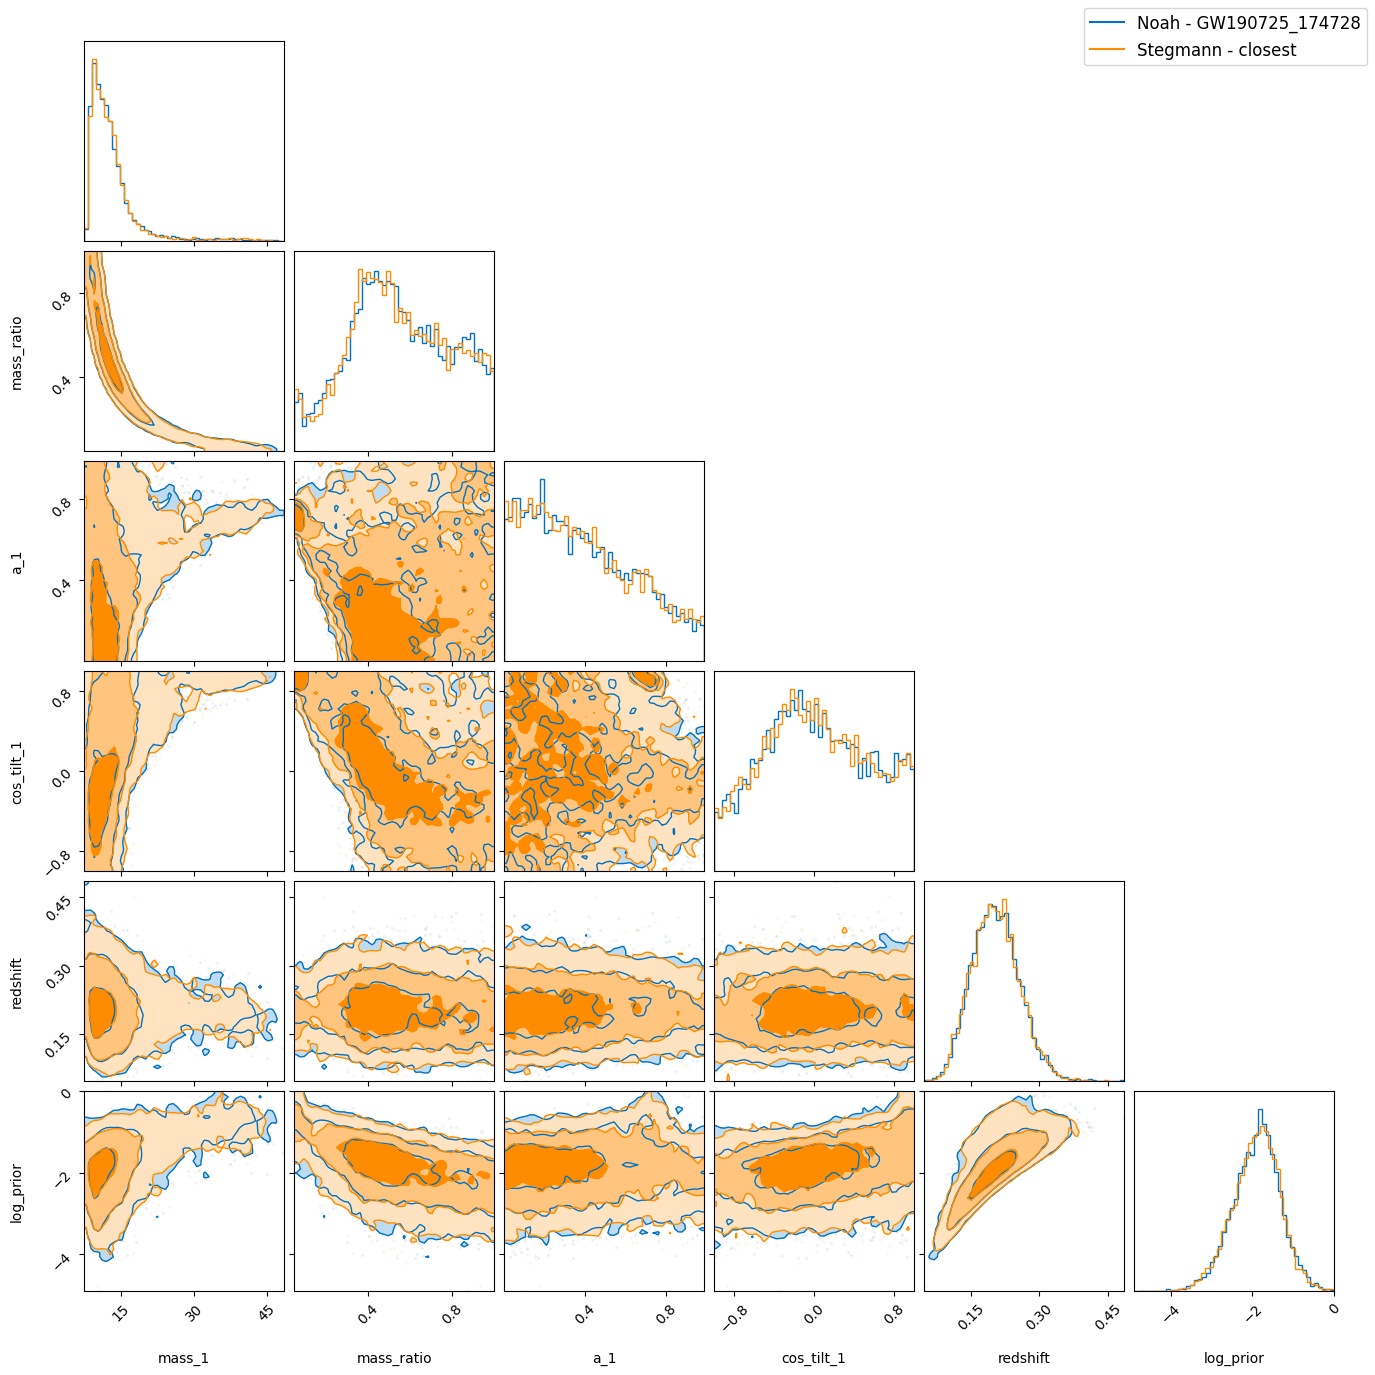

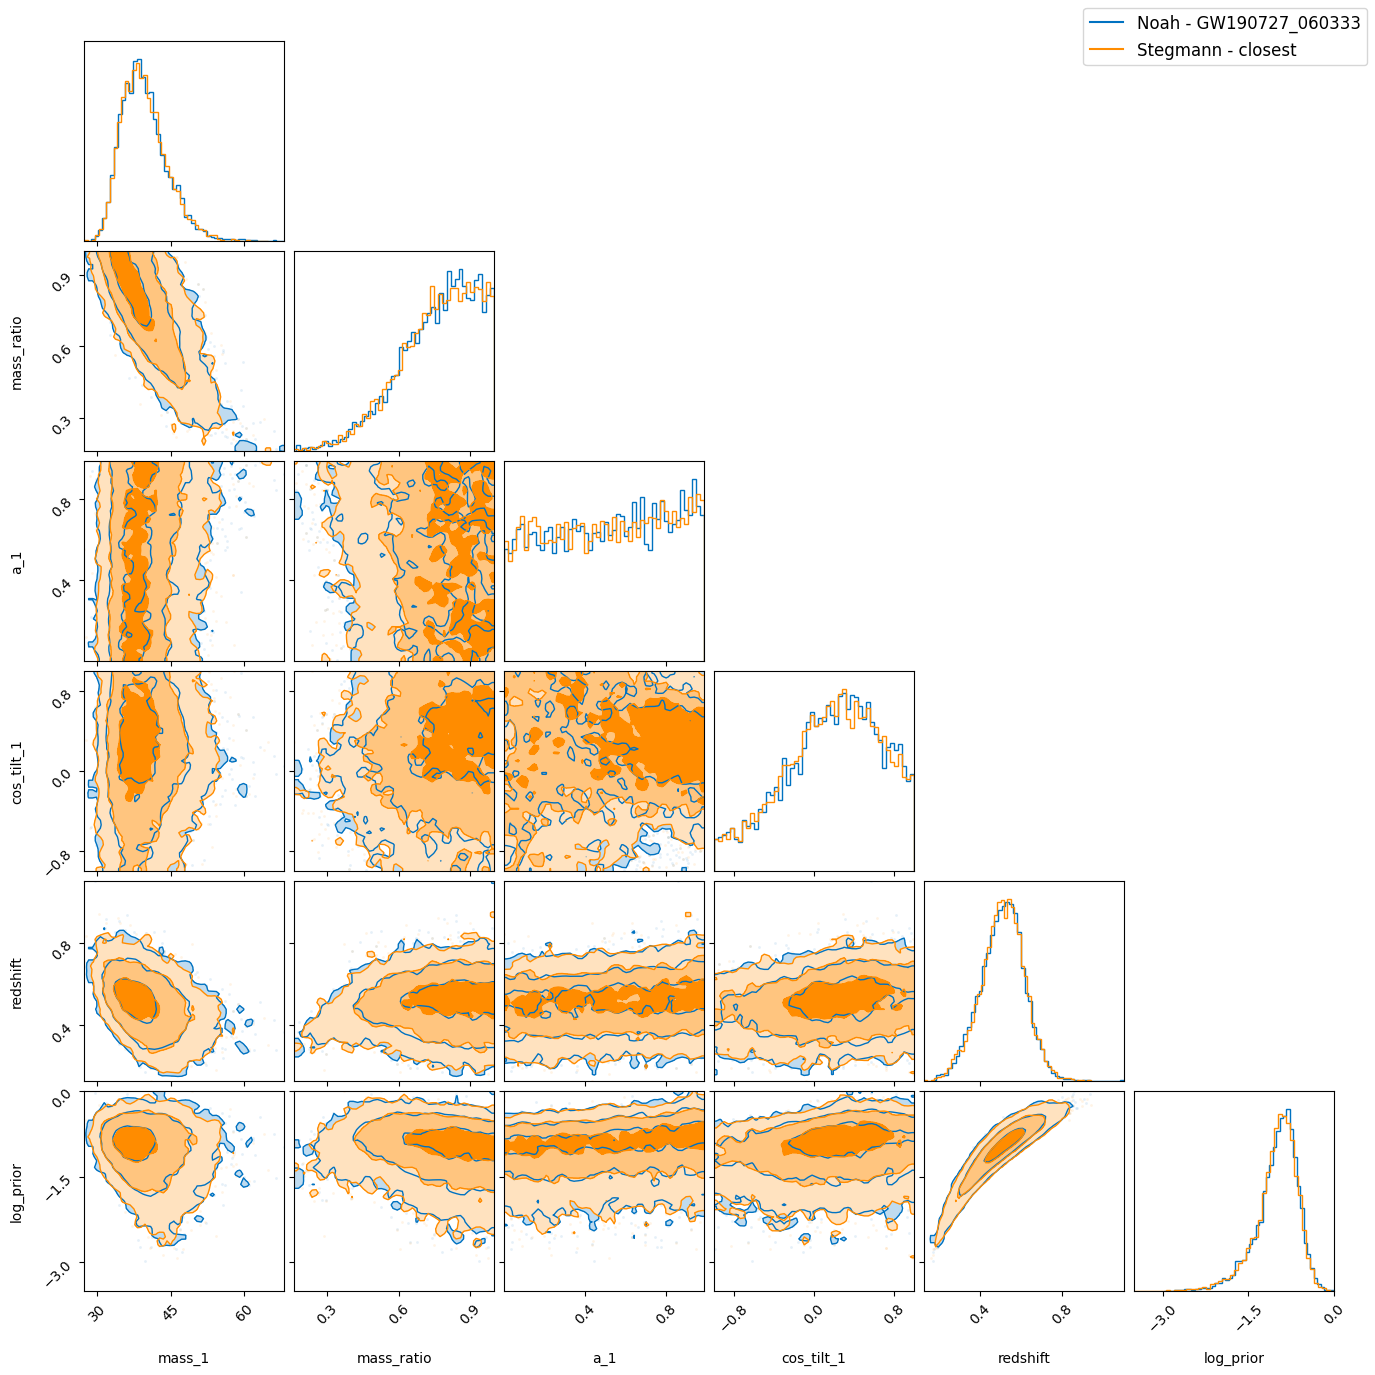

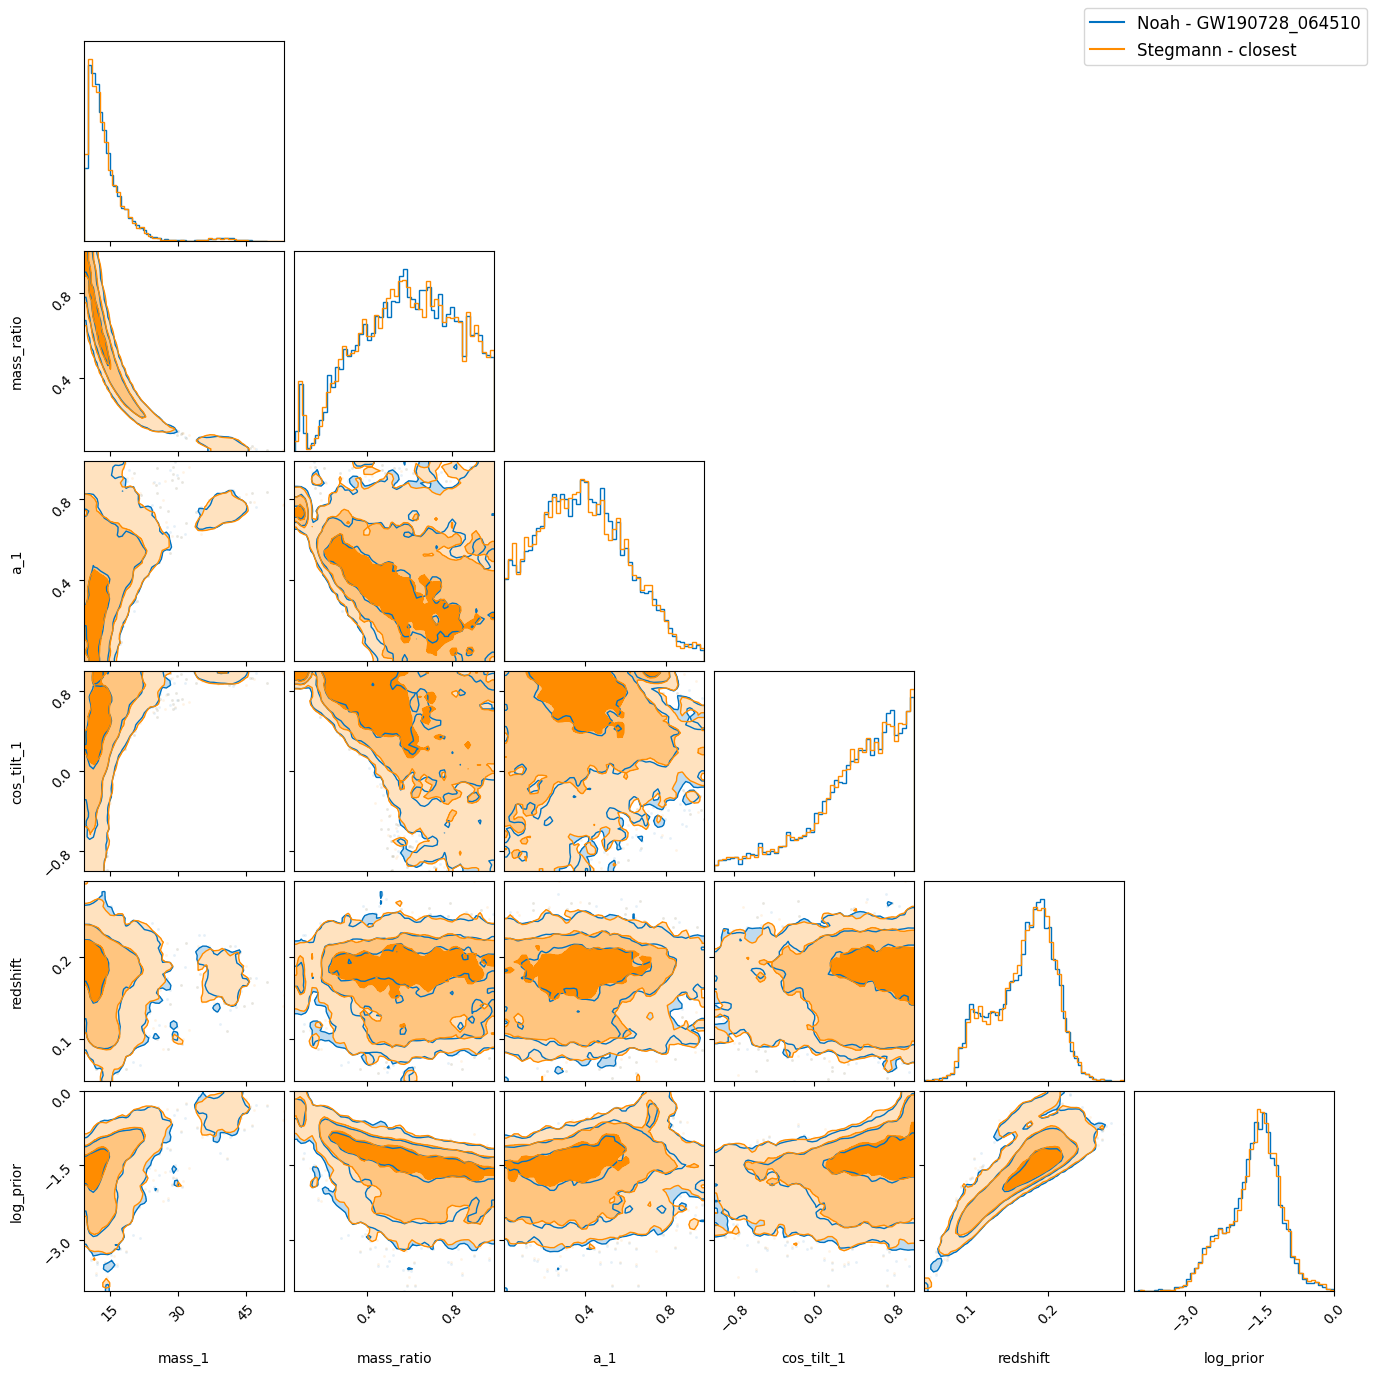

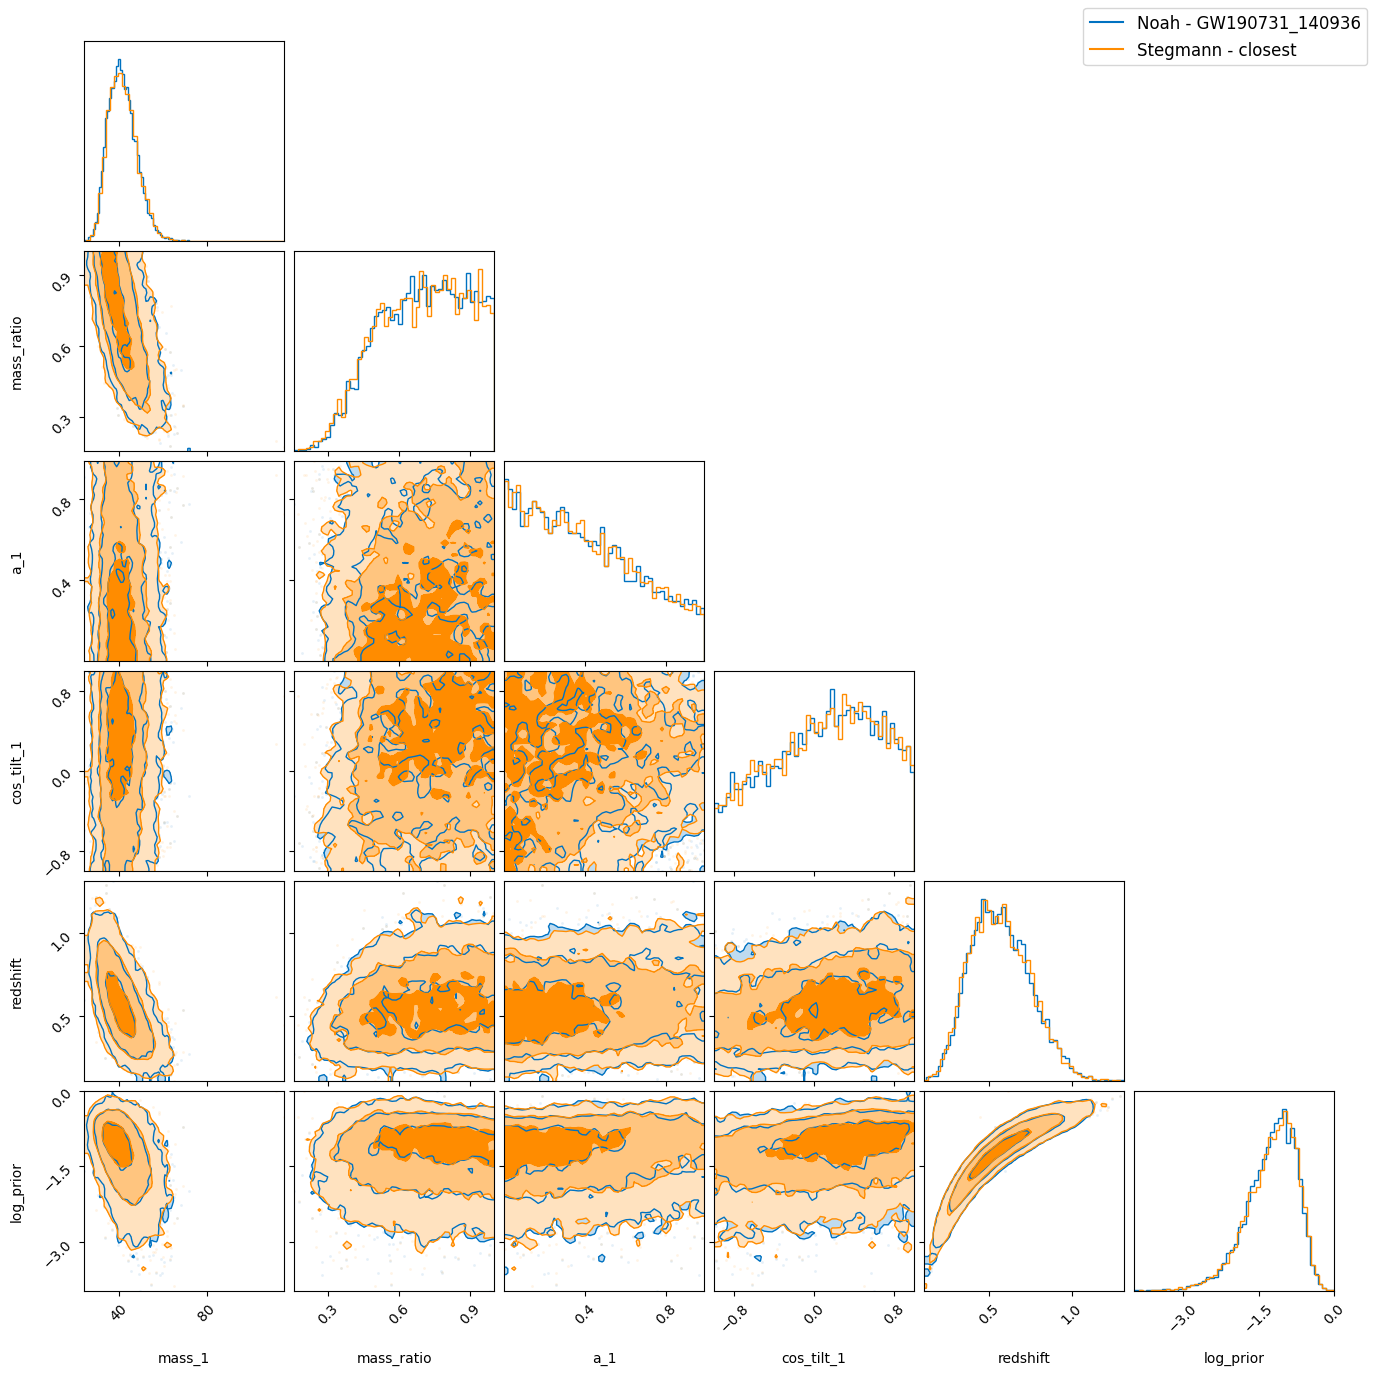

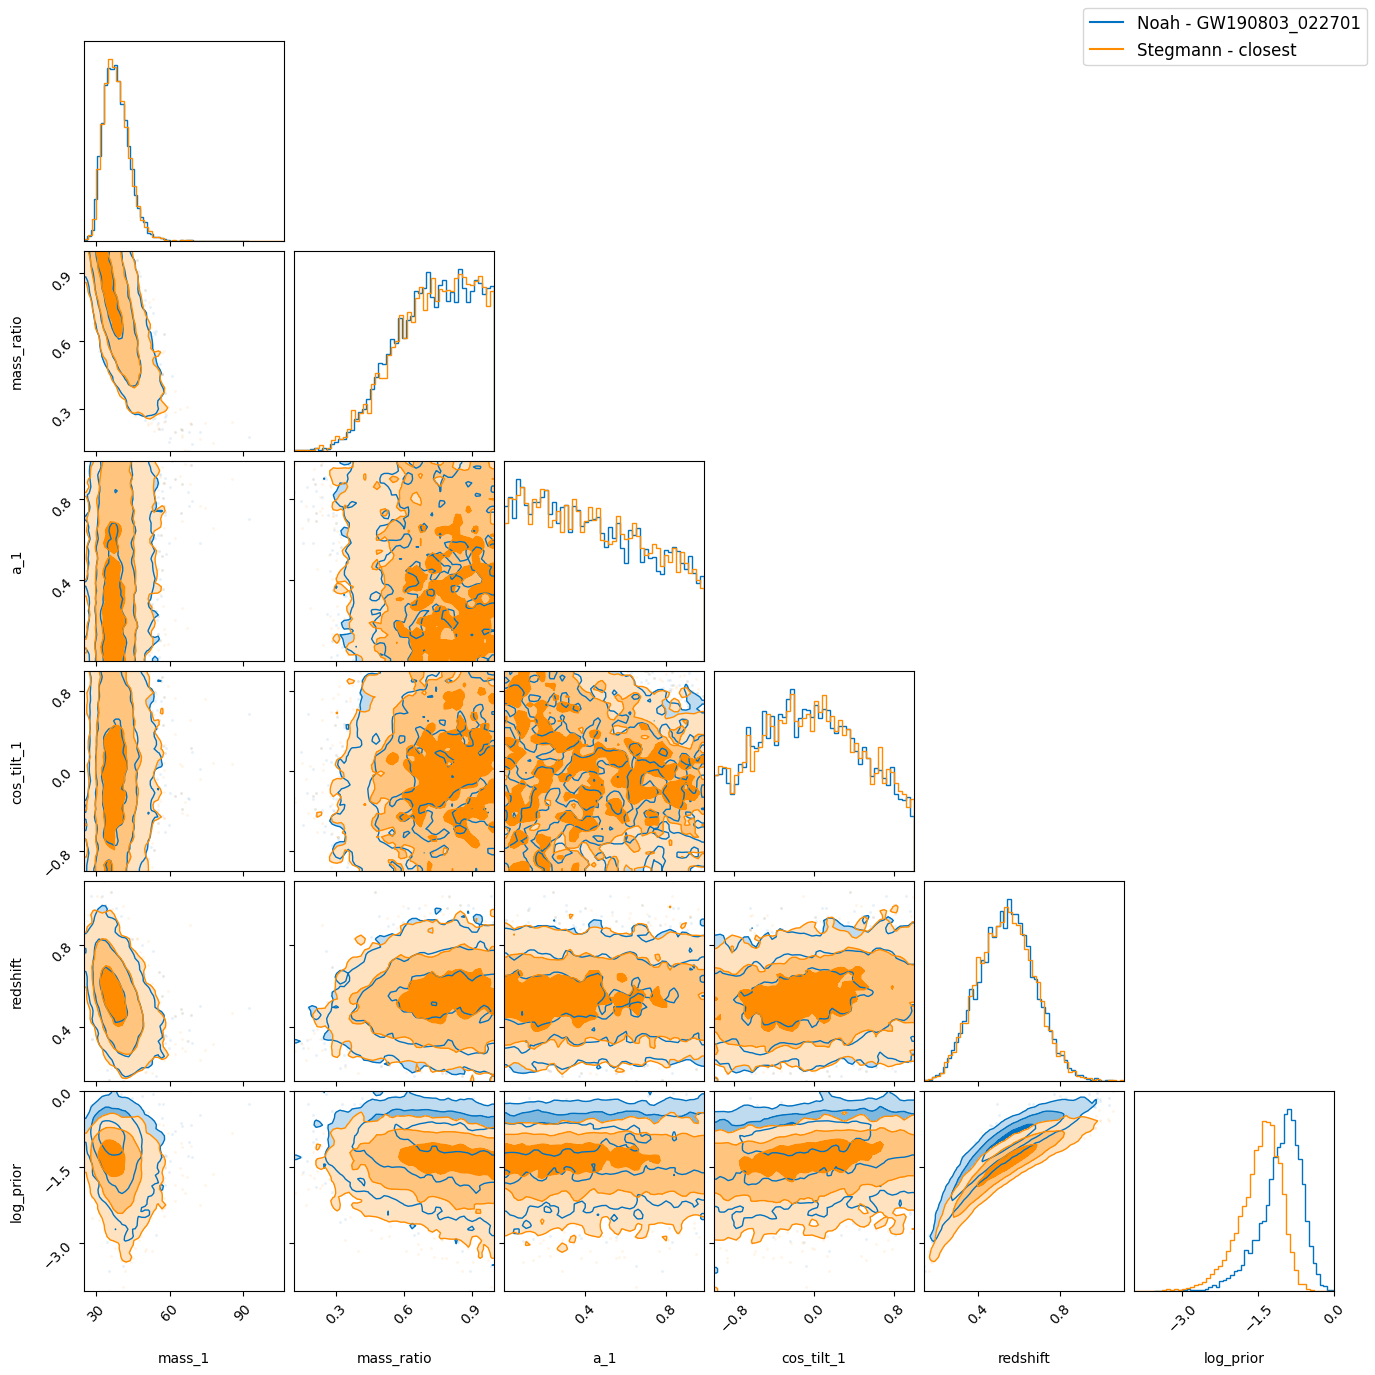

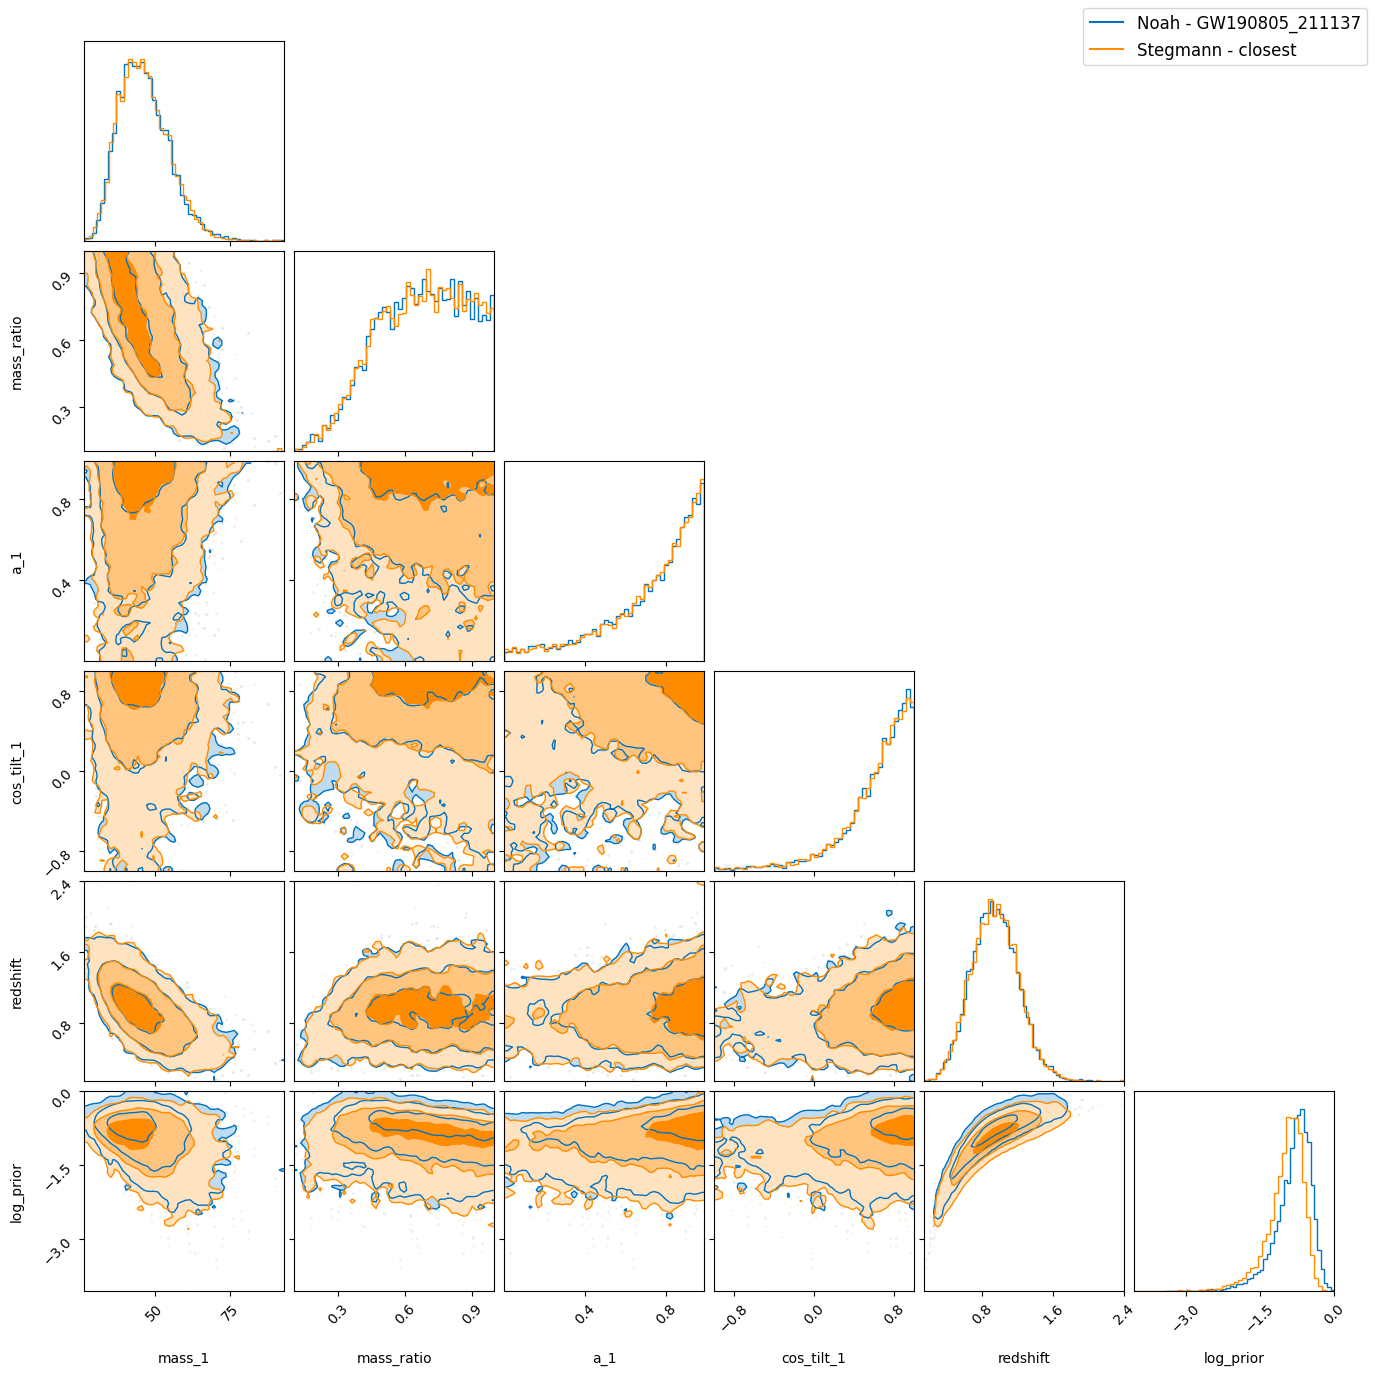

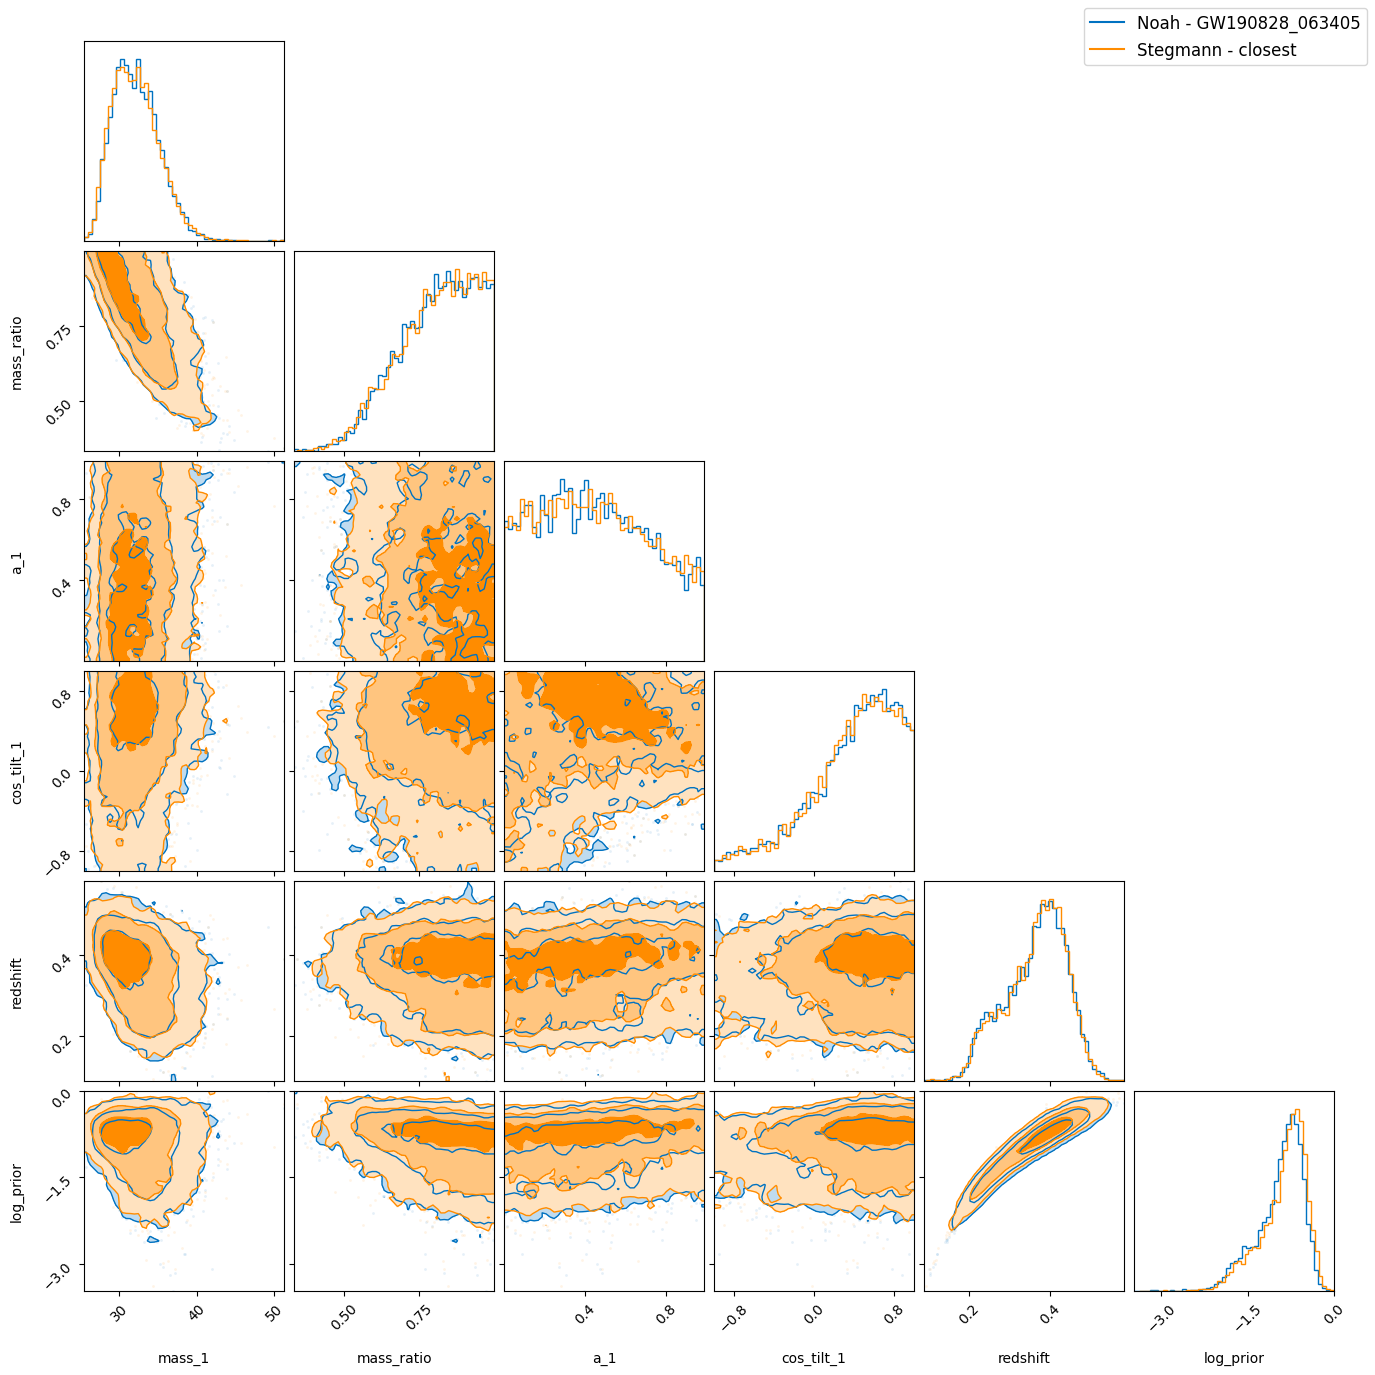

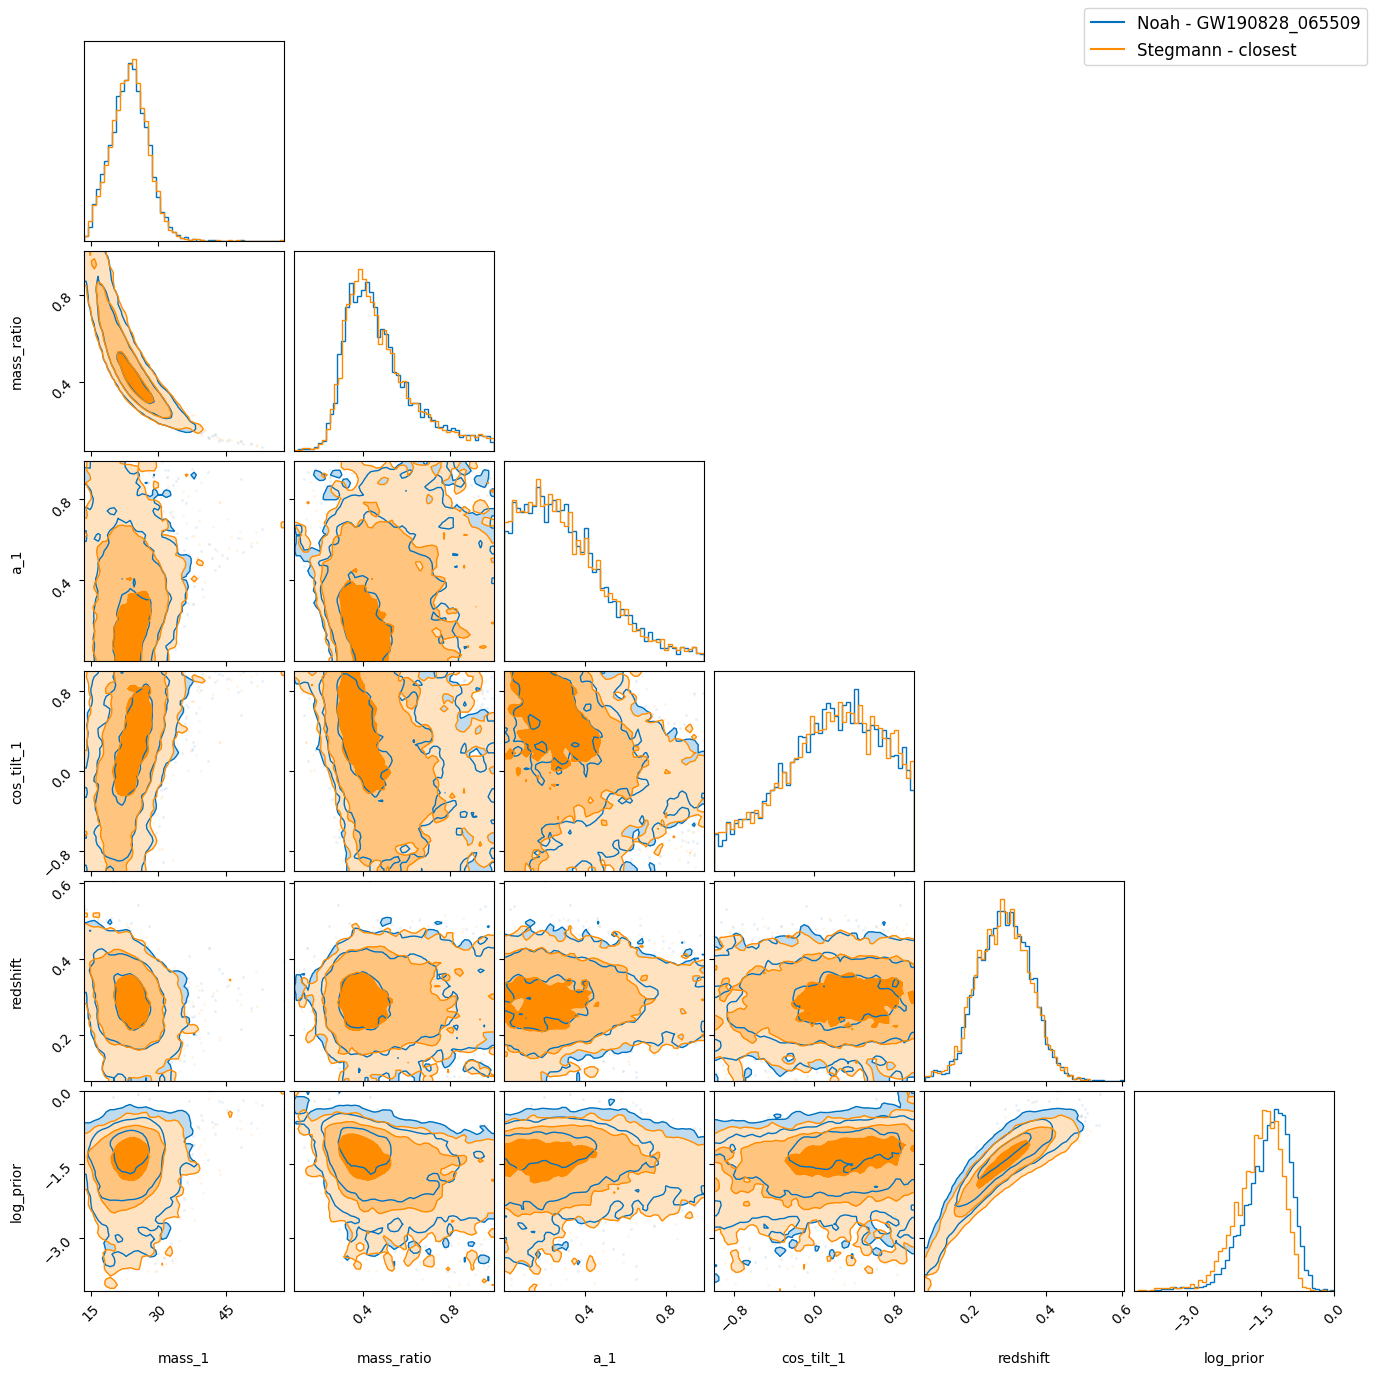

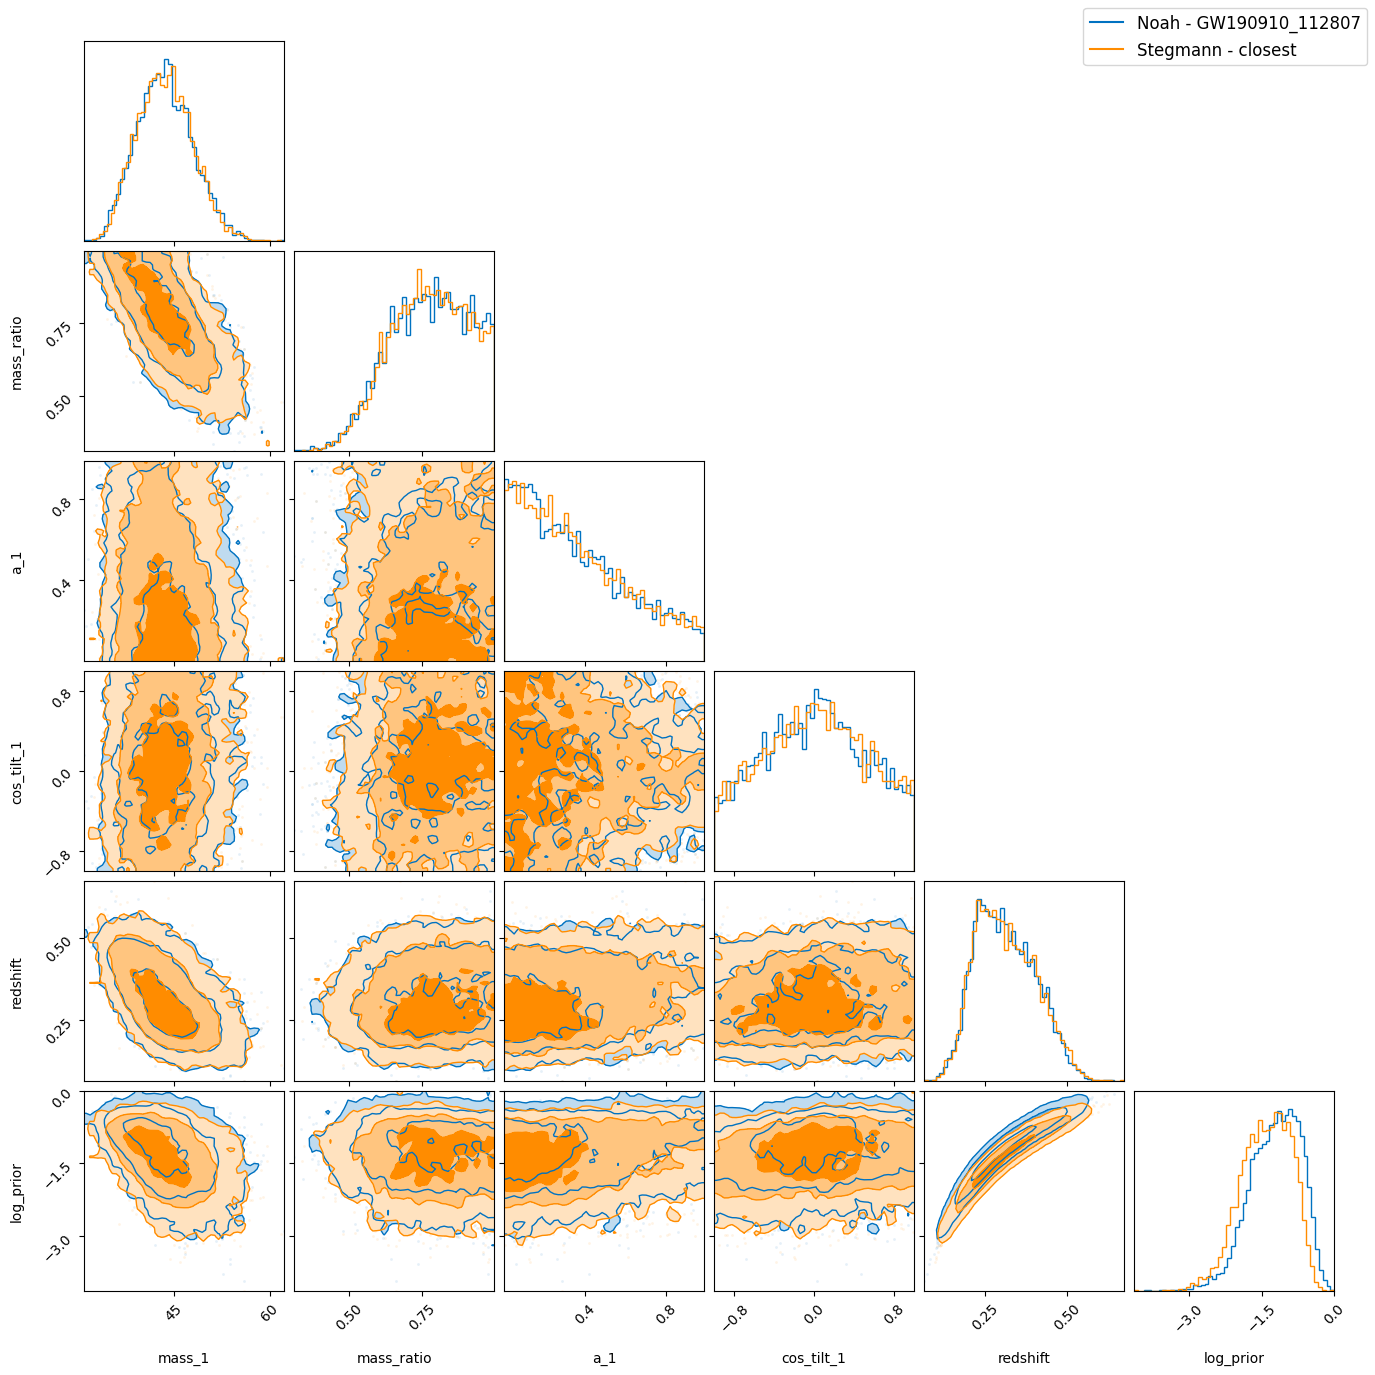

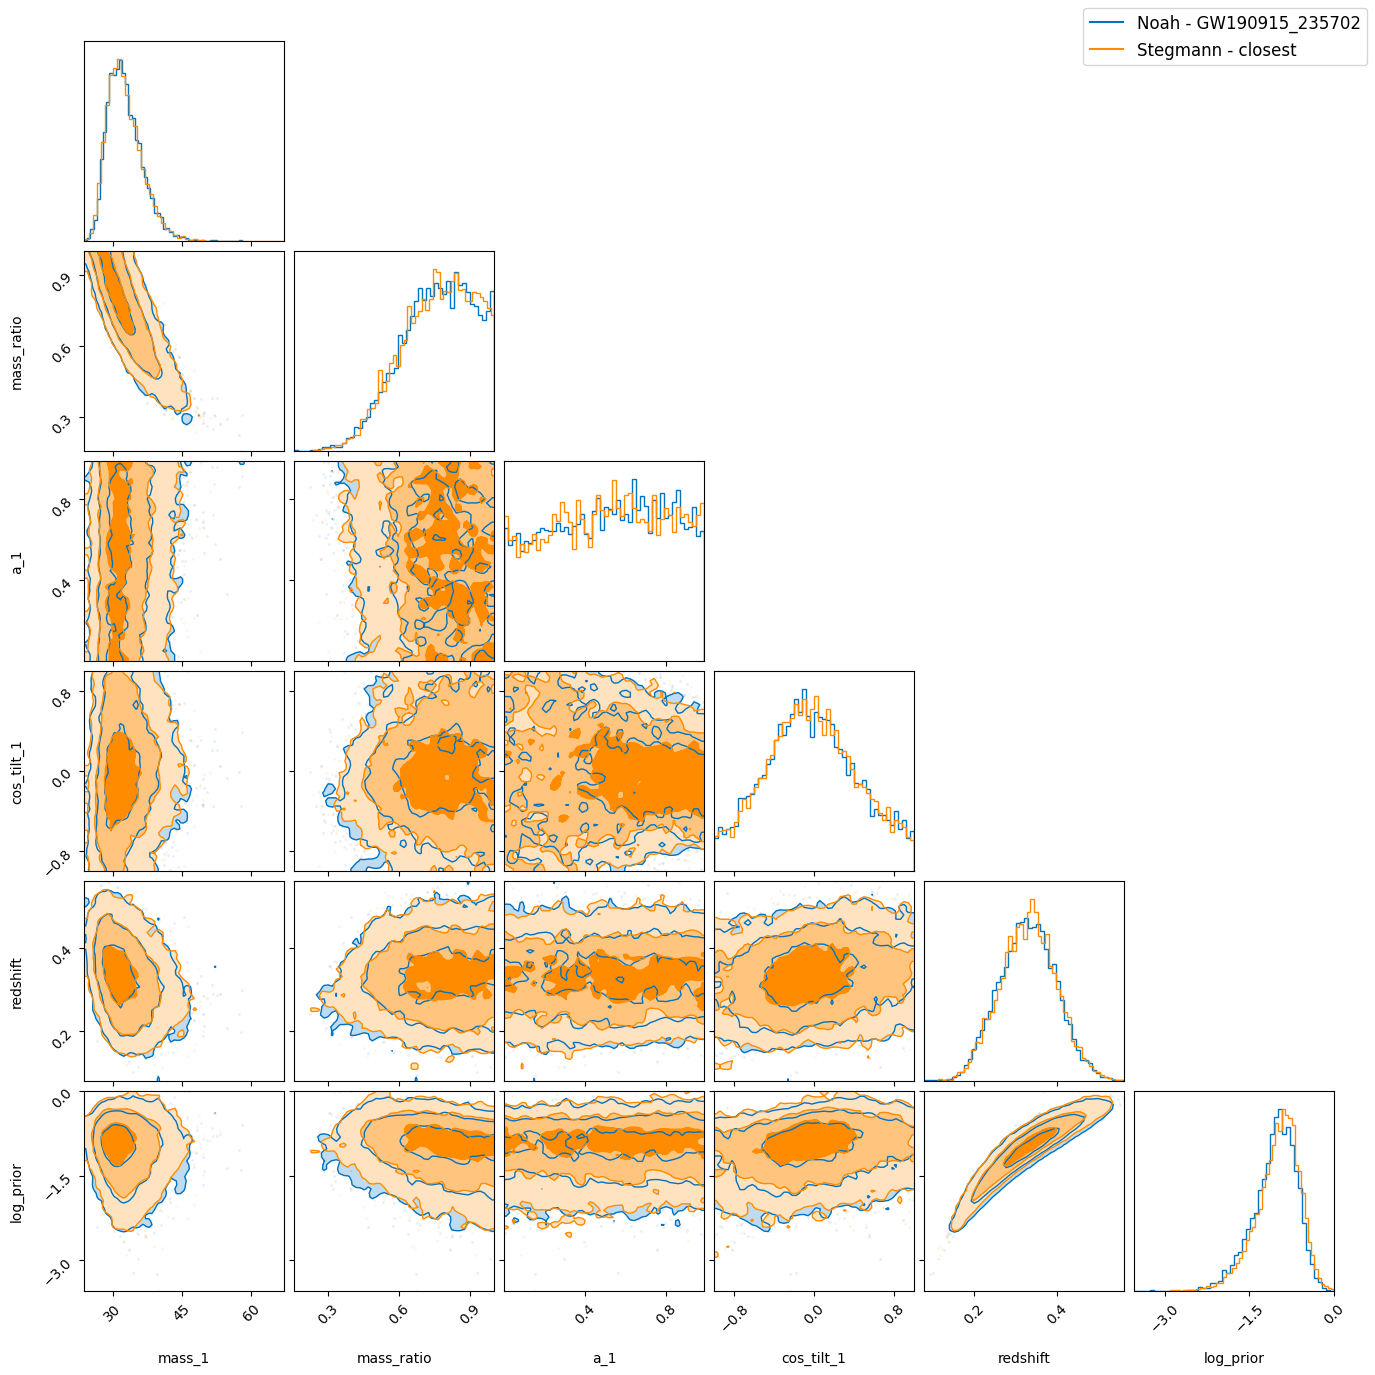

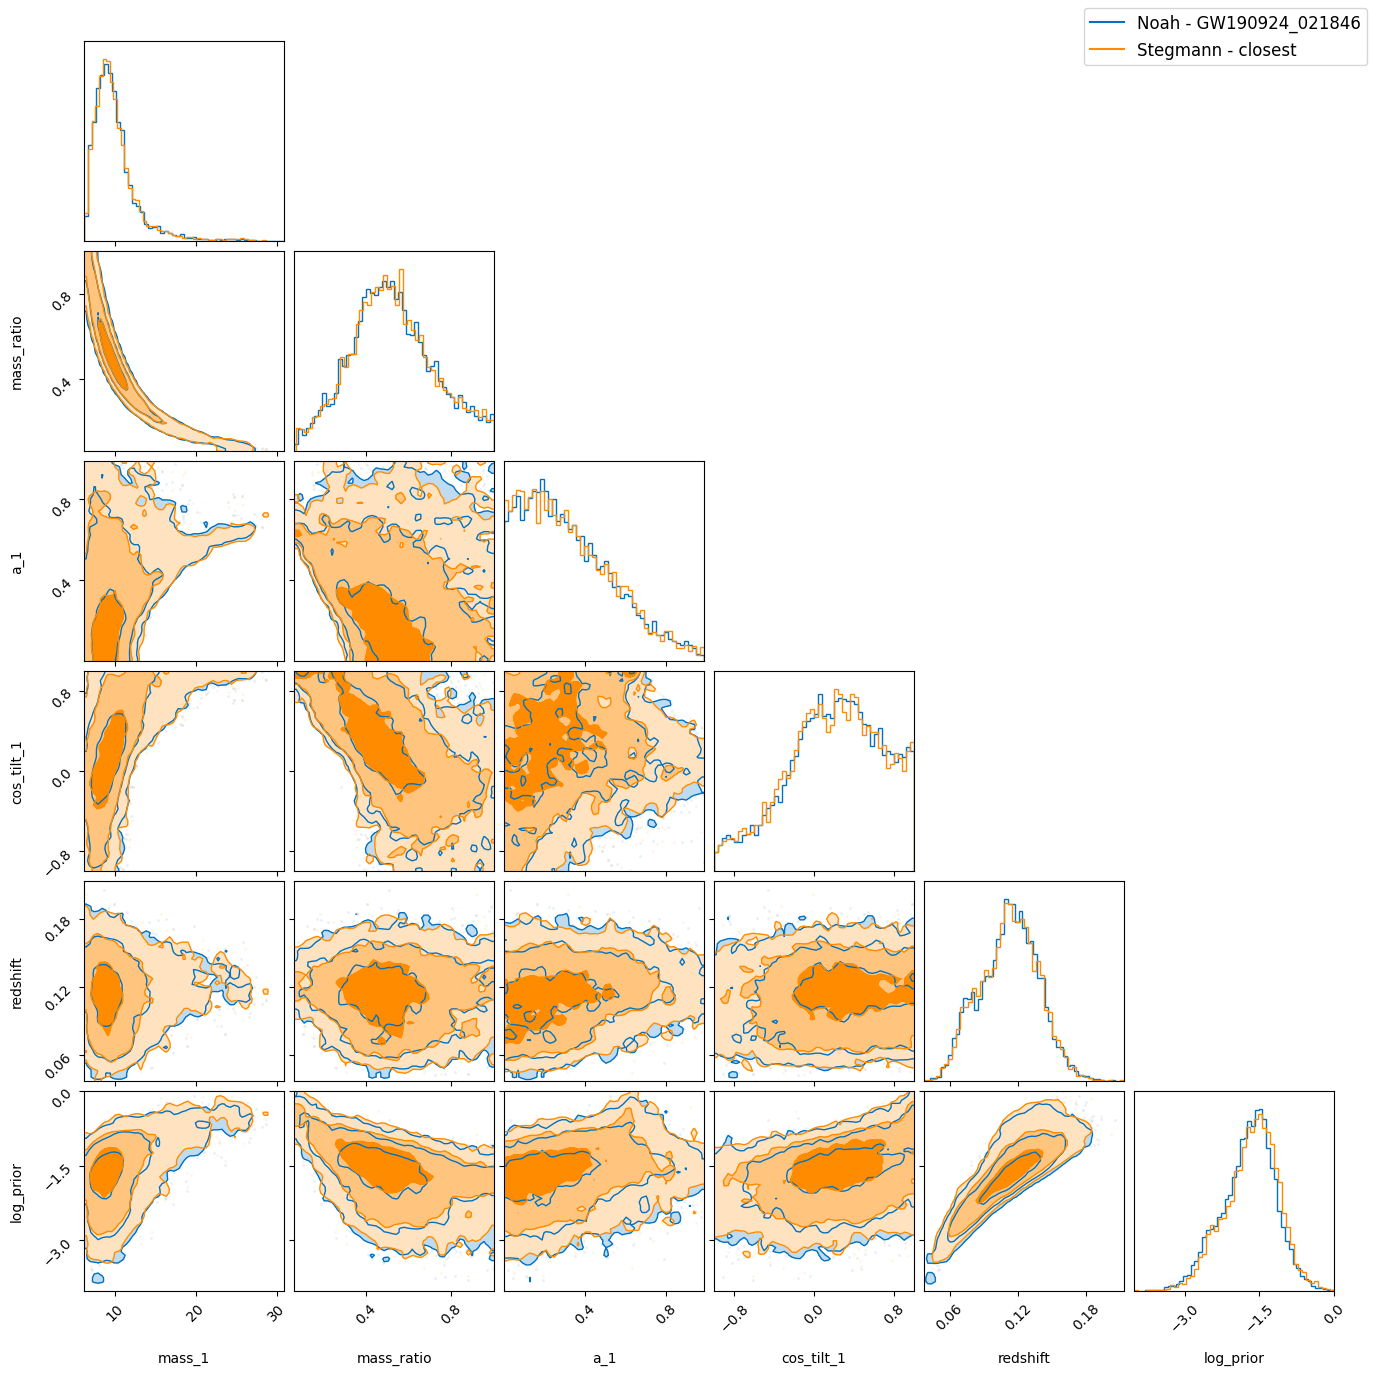

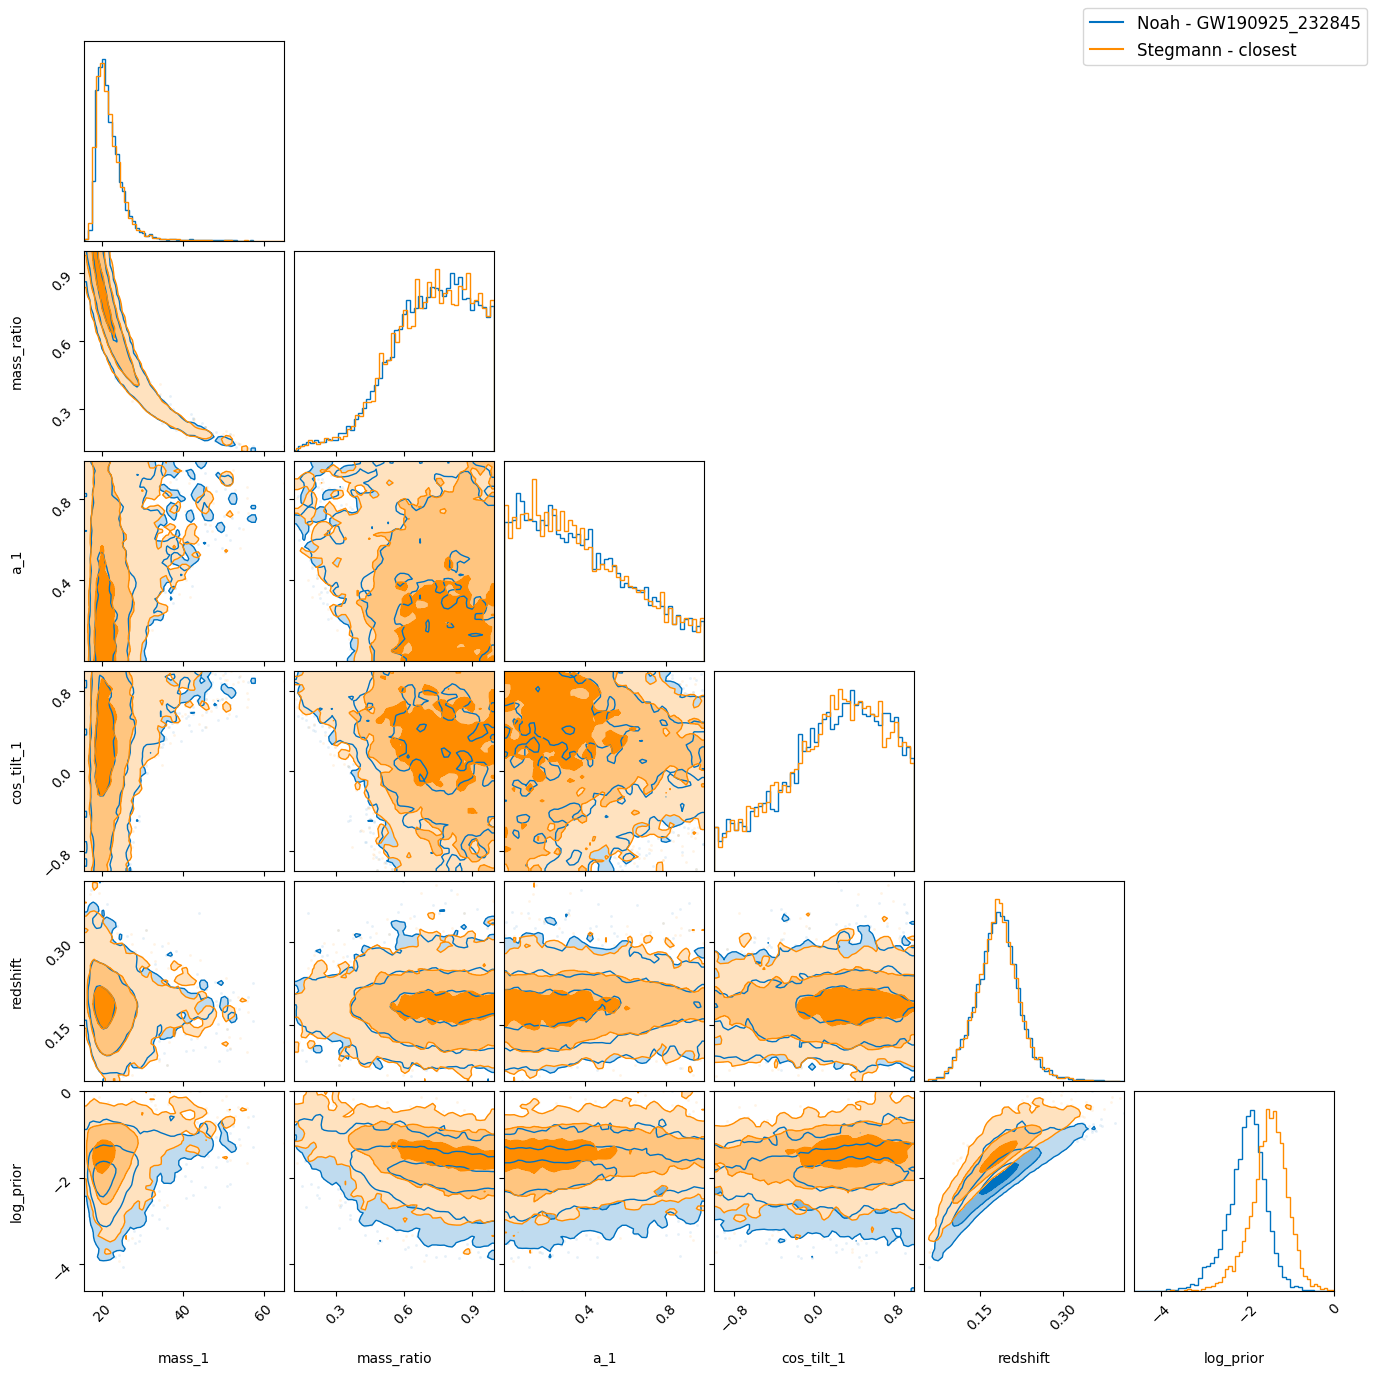

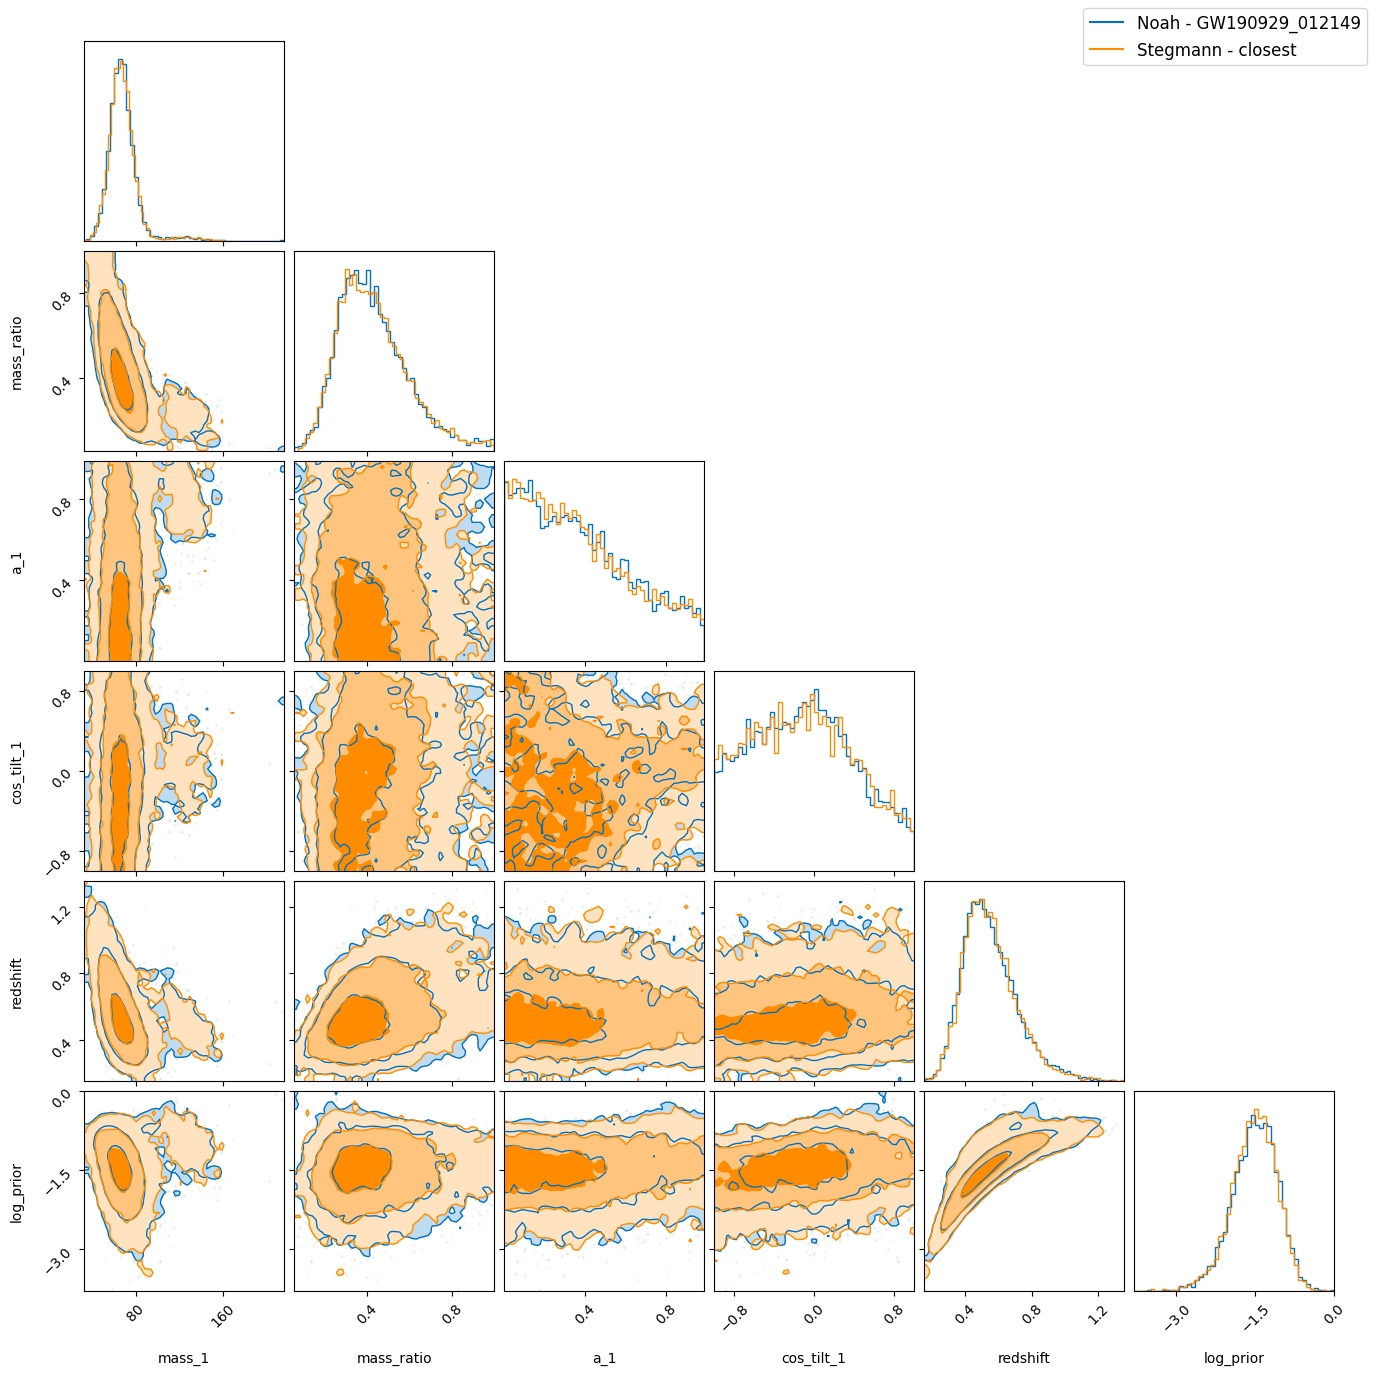

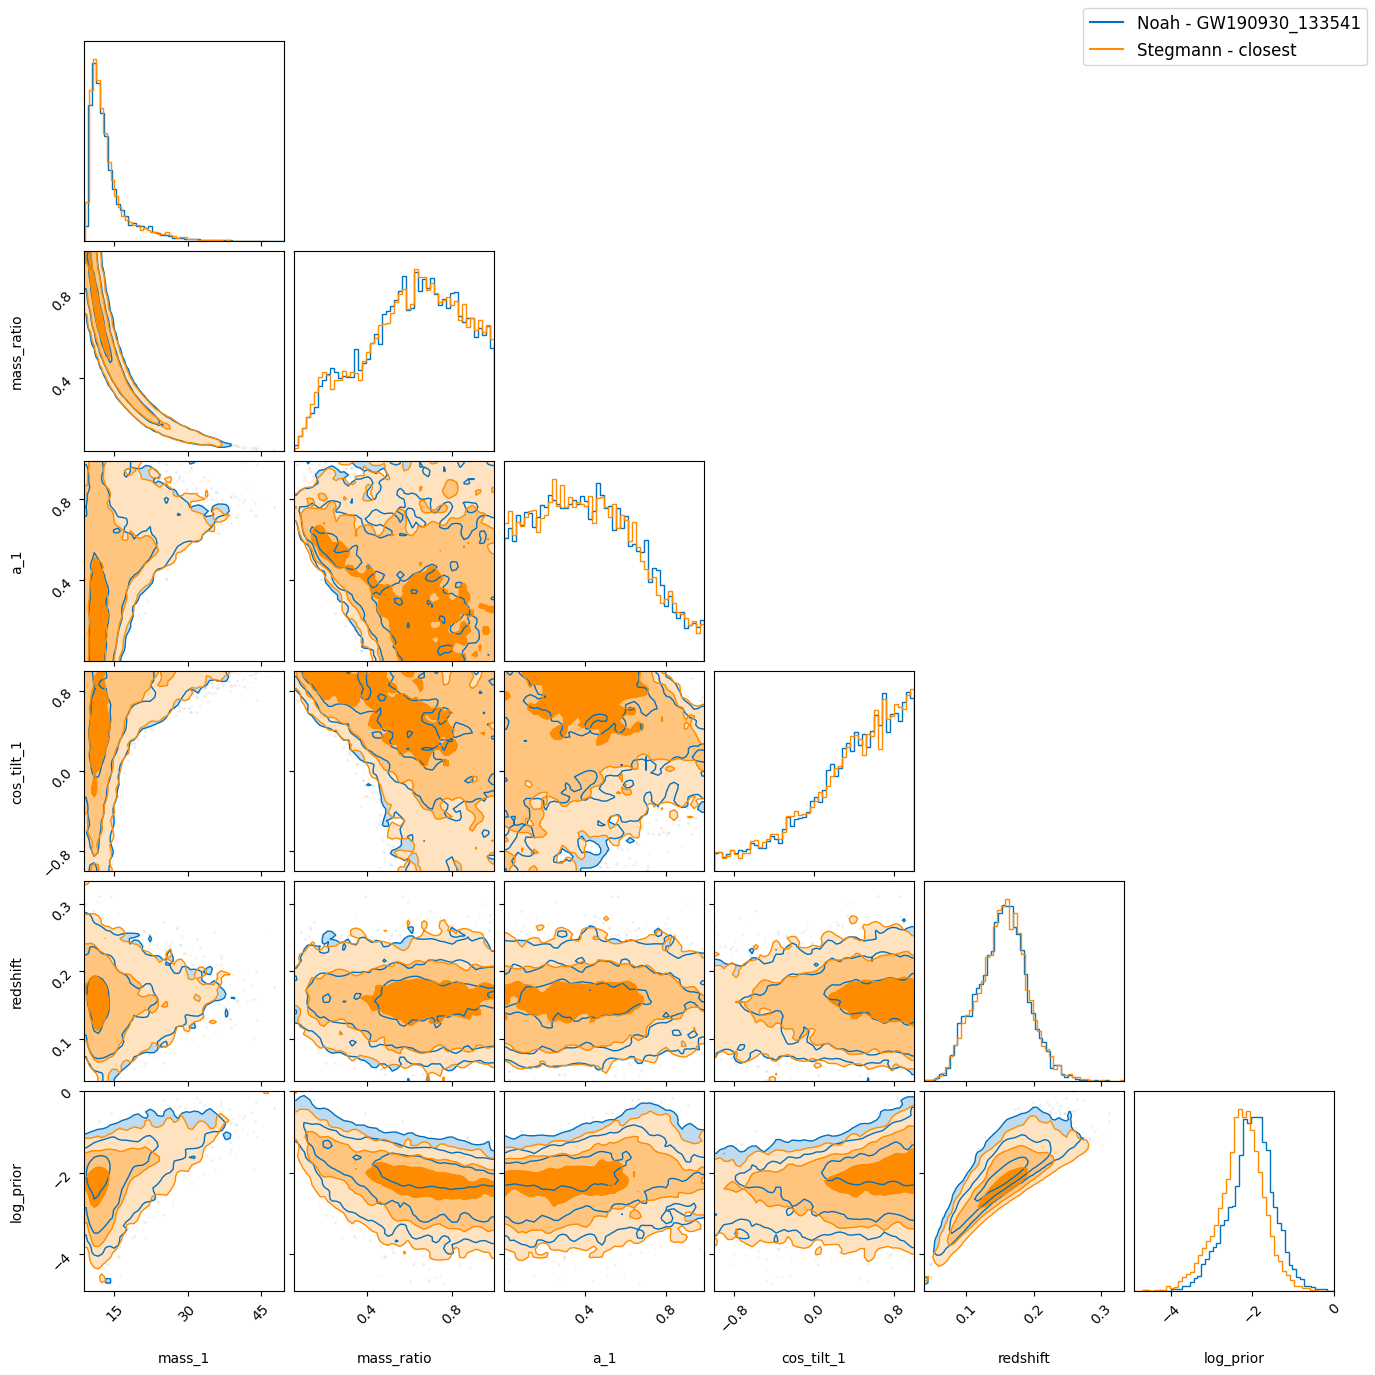

In [18]:
from scipy.stats import wasserstein_distance

matches = []

for i in weird_idxs:
    pn = posteriors[i]

    dists = []
    for j in weird_idxs:
        ps = posteriors_stegmann[j]
        dists.append(wasserstein_distance(
            pn['mass_1'],
            ps['mass_1'] 
        ))
    dists = np.array(dists)
    idx = weird_idxs[np.argmin(dists)]

    for m in matches:
        if idx == m[1]:
            raise ValueError('Duplicate match')

    matches.append((i, idx))

    fig = wrap_multiple(
        [pn, posteriors_stegmann[idx]],
        ['mass_1', 'mass_ratio', 'a_1', 'cos_tilt_1', 'redshift', 'log_prior'],
        xs_labels=[f'Noah - {events[i]}', f'Stegmann - closest']
    )

In [127]:
matches = np.array(matches)

In [128]:
np.unique(matches[:, 0]), np.unique(matches[:, 1])

(array([32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]),
 array([32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]))

In [19]:
for e, pn, ps in zip(events, posteriors, posteriors_stegmann):
    fig = wrap_multiple(
        [pn, ps],
        ['mass_1', 'mass_ratio', 'a_1', 'cos_tilt_1', 'redshift', 'log_prior'],
        xs_labels=[f'Noah', f'Stegmann']
    )
    fig.savefig(f'./events/{e}.jpg')
    plt.close()

Try to recompute prior to see if we can get the same rel distributions

In [23]:
posteriors[4]['prior']

0        73.794082
1        52.526402
2       103.811414
3        73.249570
4        63.967423
           ...    
6908     50.910439
6909     74.962321
6910    121.287813
6911    190.662082
6912    133.452602
Name: prior, Length: 6913, dtype: float64

In [26]:
from bilby.gw.prior import UniformSourceFrame

posterior = posteriors[4]

def eval_at_z(z):
    return UniformSourceFrame(
        minimum=posterior['redshift'].min(),
        maximum=posterior['redshift'].max(),
        cosmology='Planck15_LAL',
        name='redshift',
    ).prob(z) * (1 + z)**2

zs = np.linspace(
    posterior['redshift'].min(),
    posterior['redshift'].max(),
    10_000
)

pz = eval_at_z(zs)
norm = np.trapezoid(pz, zs)



new_prior = UniformSourceFrame(
    minimum=posterior['redshift'].min(),
    maximum=posterior['redshift'].max(),
    cosmology='Planck15_LAL',
    name='redshift',
).prob(posterior['redshift']) * (1 + posterior['redshift'])**2

new_prior /= norm

new_prior *= posterior['mass_1']
log_new_prior = np.log(new_prior)

In [28]:
new_prior

0        89.935109
1        64.015536
2       126.518157
3        89.271531
4        77.958990
           ...    
6908     62.046105
6909     91.358846
6910    147.817158
6911    232.365662
6912    162.642799
Name: redshift, Length: 6913, dtype: float64

In [ ]:
posterior['redshift'].min(), posteriors_stegmann[4]['redshift'].min()

(np.float64(0.017607448551392273), np.float64(0.020998391443797743))

In [21]:
posterior['redshift'].max(), posteriors_stegmann[4]['redshift'].max()

(np.float64(0.1161575766175633), np.float64(0.12303073804651139))

In [ ]:
import h5py

import wcosmo
from wcosmo import dDLdz
from astropy.cosmology import Planck15

from astropy import units

MPC3_TO_GPC3 = 1e-9

with h5py.File('/home/rp.o4/catalogs/GWTC-2.1/data-release/IGWN-GWTC2p1-v2-GW170608_020116_PEDataRelease_mixed_cosmo.h5', 'r') as f:
    samples = f['C01:IMRPhenomXPHM']['posterior_samples'][:]
    sample_log_prior = samples['log_prior']

    samples_prior = np.exp(sample_log_prior)

    # convert from prior in detector-frame component masses to source-frame
    samples_prior *= (1 + samples['redshift'])**2
    samples_prior *= samples['mass_1_source']

    dvc_dz = Planck15.differential_comoving_volume(samples['redshift'])
    dvc_dz = 4 * np.pi * MPC3_TO_GPC3 * dvc_dz.value

    samples_prior *= dvc_dz / (1 + samples['redshift'])

    sample_log_prior = np.log(samples_prior)

    #sample_log_prior += np.log(dvc_dz / (1 + samples['redshift']))

In [78]:
sample_log_prior

array([292.70680098, 288.26193412, 284.53084348, ..., 278.53280526,
       269.74761363, 262.93419621], shape=(219080,))

In [51]:
posteriors_jack = pd.read_pickle('/home/noah.wolfe/projects/tilts-and-kicks/data/lvk/jack-copy/posteriors.pkl')

In [64]:
for i in range(len(posteriors_jack)):
    posteriors_jack[i]['log_prior'] = np.log(posteriors_jack[i]['prior'])
    posteriors_jack[i]['log_prior'] -= posteriors_jack[i]['log_prior'].max()

(array([5.04561892e-06, 0.00000000e+00, 1.51368568e-05, 5.04561892e-06,
        2.52280946e-05, 1.51368568e-05, 1.51368568e-05, 5.55018082e-05,
        8.07299028e-05, 1.16049235e-04, 2.52280946e-04, 3.17873992e-04,
        3.83467038e-04, 6.76112936e-04, 1.10499054e-03, 1.68019110e-03,
        2.15952490e-03, 3.31497163e-03, 4.60665008e-03, 6.48866594e-03,
        9.29907568e-03, 1.21548960e-02, 1.64537633e-02, 2.16860701e-02,
        2.75490793e-02, 3.47542231e-02, 4.38010179e-02, 5.16974115e-02,
        6.04616516e-02, 6.84841857e-02, 7.76066647e-02, 8.19913075e-02,
        8.51650018e-02, 8.51347281e-02, 8.19660794e-02, 7.58356524e-02,
        6.69049069e-02, 5.48206496e-02, 4.39523864e-02, 3.18378554e-02,
        2.18979861e-02, 1.39763644e-02, 8.52709598e-03, 4.51582894e-03,
        2.08384062e-03, 9.58667596e-04, 3.68330181e-04, 1.51368568e-04,
        3.02737135e-05, 1.00912378e-05]),
 array([-45.23273261, -44.32807796, -43.42342331, -42.51876866,
        -41.614114  , -40.7094

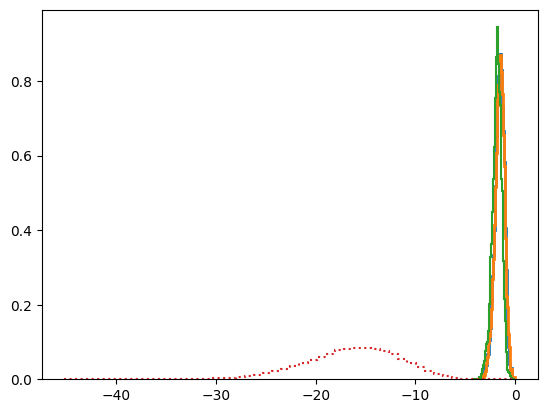

In [75]:
fig, ax = plt.subplots()
ax.hist(posterior['log_prior'], histtype='step', bins=50, density=True, lw=2)
ax.hist(posteriors_jack[4]['log_prior'], histtype='step', bins=50, density=True, lw=2)
ax.hist(posteriors_stegmann[4]['log_prior'], histtype='step', bins=50, density=True, lw=1.5)

"""
ax.hist(
    log_new_prior - np.max(log_new_prior),
    histtype='step',
    bins=50,
    density=True,
    linestyle='--',
    lw=1.5
);
"""

ax.hist(
    sample_log_prior - sample_log_prior.max(),
    histtype='step',
    bins=50,
    density=True,
    linestyle=':',
    lw=1.5
)

In [22]:
posteriors_stegmann[4]['prior']

188514    0.227546
144898    0.097367
12960     0.046689
130471    0.177693
213364    0.045586
            ...   
22761     0.166896
25307     0.154551
93649     0.081983
157093    0.069526
195192    0.210055
Name: prior, Length: 6913, dtype: float64

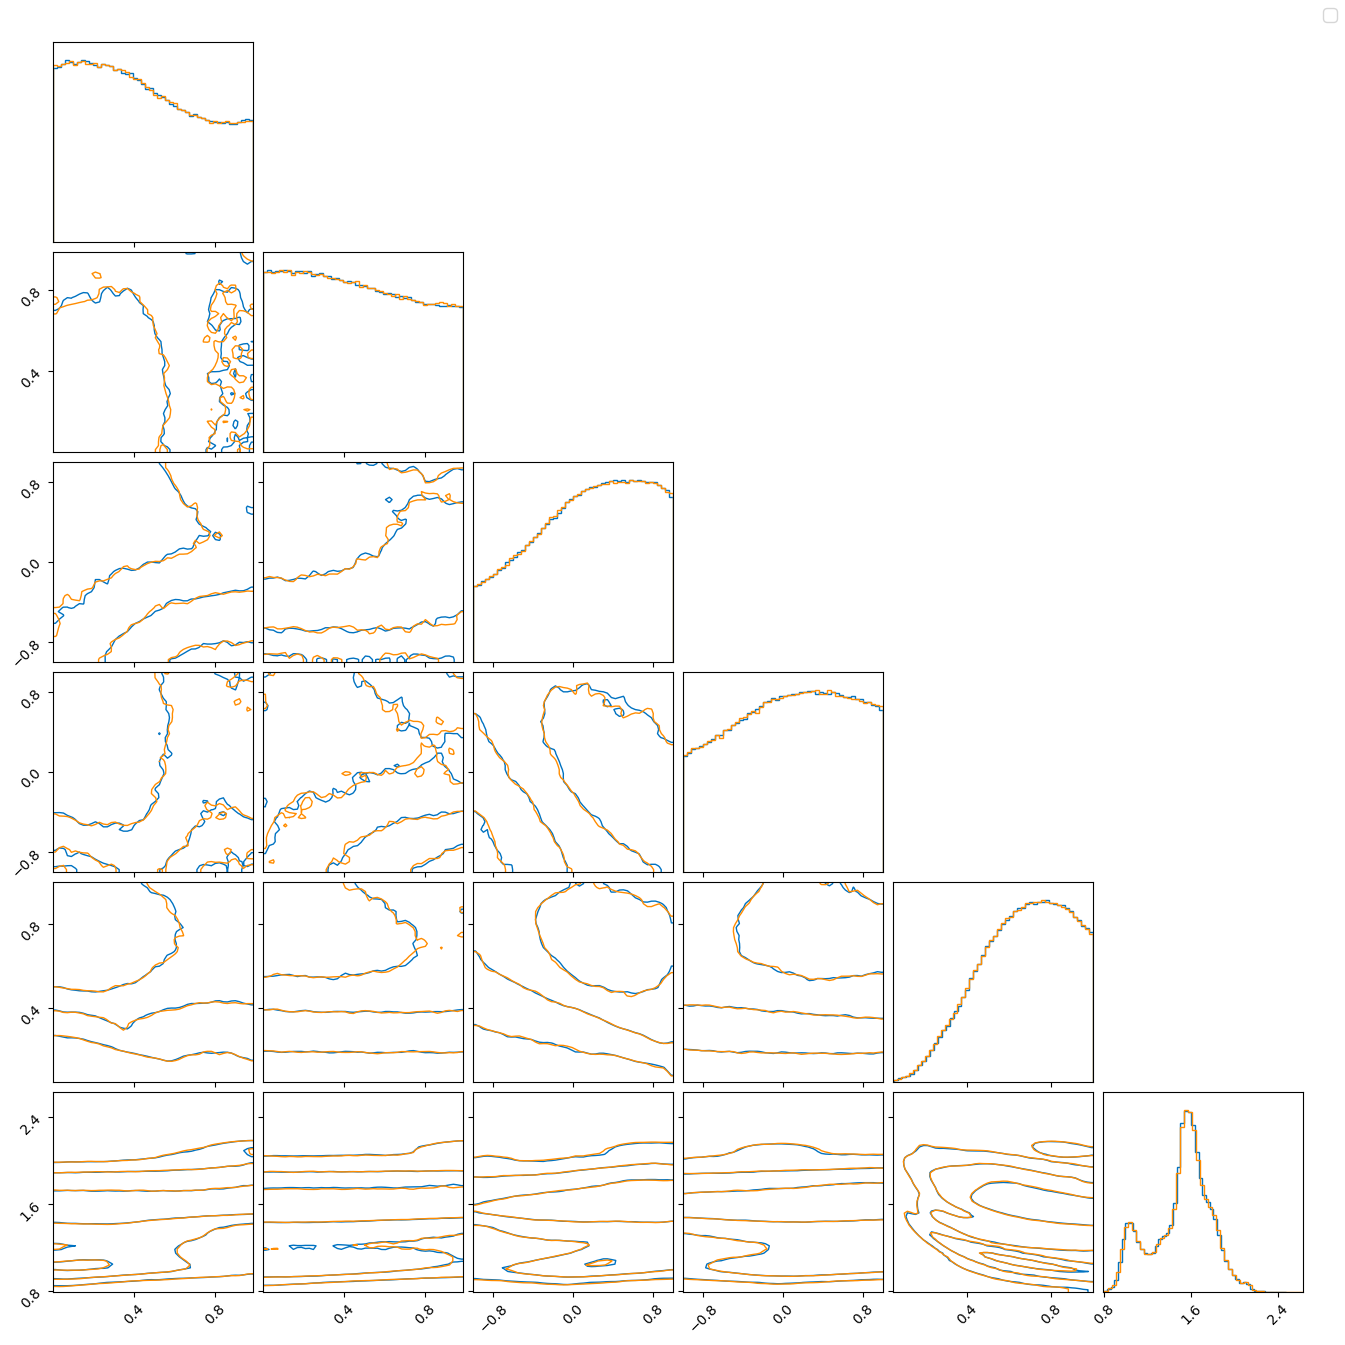

In [16]:
plot_multiple(
    [
        np.column_stack([
            posteriors['a_1'].flatten(),
            posteriors['a_2'].flatten(),
            posteriors['cos_tilt_1'].flatten(),
            posteriors['cos_tilt_2'].flatten(),
            posteriors['mass_ratio'].flatten(),
            np.log10(posteriors['mass_1'].flatten())
        ]),
        np.column_stack([
            posteriors_stegmann['a_1'].flatten(),
            posteriors_stegmann['a_2'].flatten(),
            posteriors_stegmann['cos_tilt_1'].flatten(),
            posteriors_stegmann['cos_tilt_2'].flatten(),
            posteriors_stegmann['mass_ratio'].flatten(),
            np.log10(posteriors_stegmann['mass_1'].flatten())
        ])    
    ],
    plot_datapoints=False,
    fill_contours=False,
    no_fill_contours=True,
    levels=(0.5, 0.9, 0.99)
);

In [22]:
posteriors_stegmann['mass_1']

array([[34.90424173, 31.7821926 , 34.78075579, ..., 32.40410484,
        38.27086819, 37.81207449],
       [29.66274623, 22.90904947, 19.10687173, ..., 19.64571789,
        42.52284106, 21.560132  ],
       [12.95822666, 10.07653814, 11.98672838, ..., 10.92832095,
        13.10643817, 13.34223486],
       ...,
       [45.16656739, 43.42528522, 43.6169016 , ..., 44.98138636,
        47.60651875, 48.5650417 ],
       [41.89491481, 46.19636263, 62.70322596, ..., 47.17869639,
        51.61418538, 60.49565568],
       [37.94016875, 37.91253766, 24.02464295, ..., 23.35116886,
        31.40675231, 33.72879162]], shape=(153, 6913))

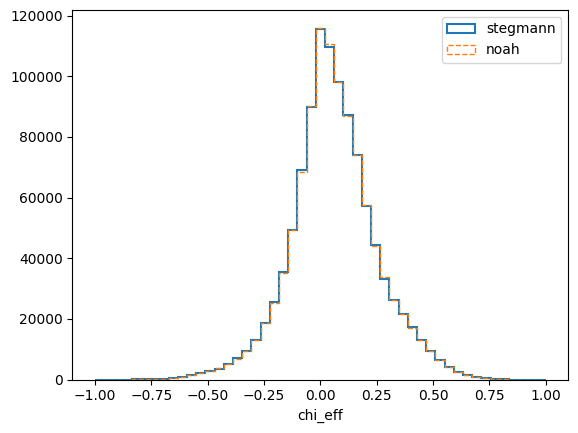

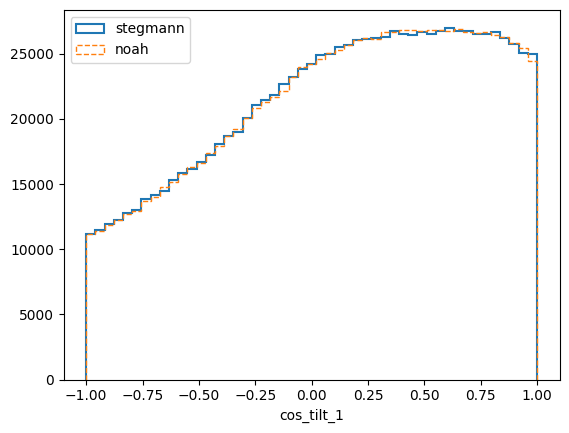

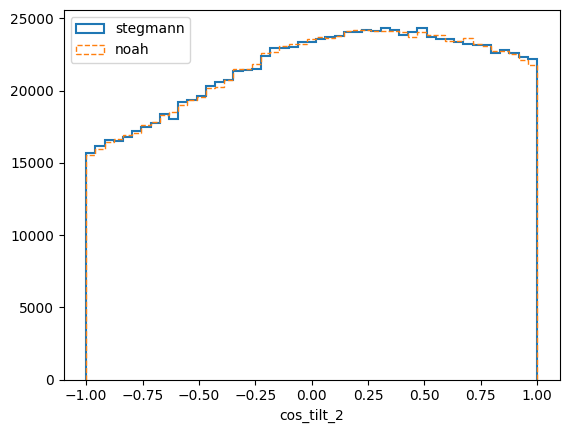

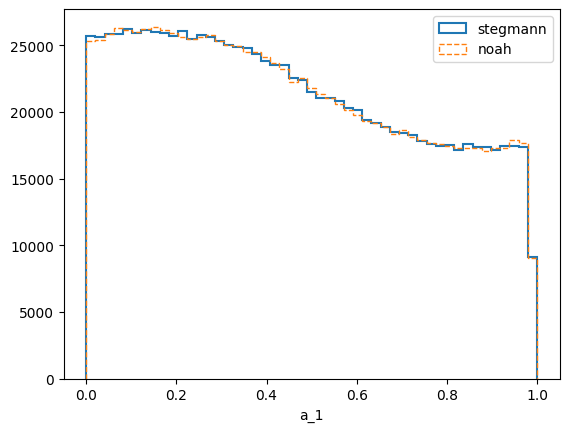

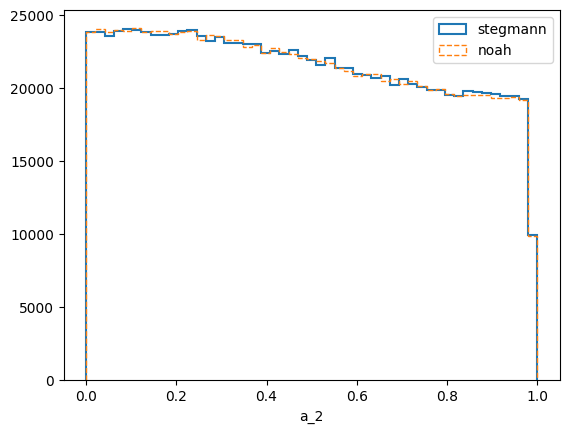

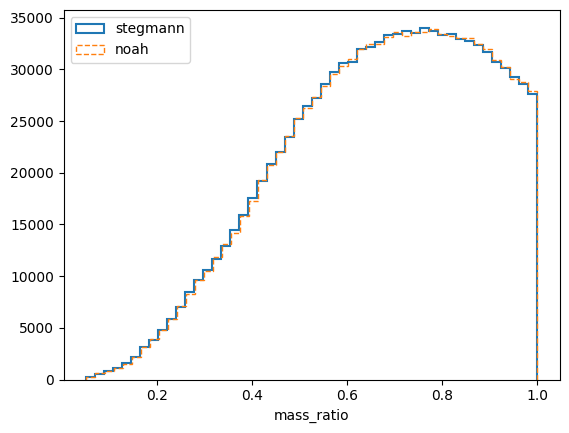

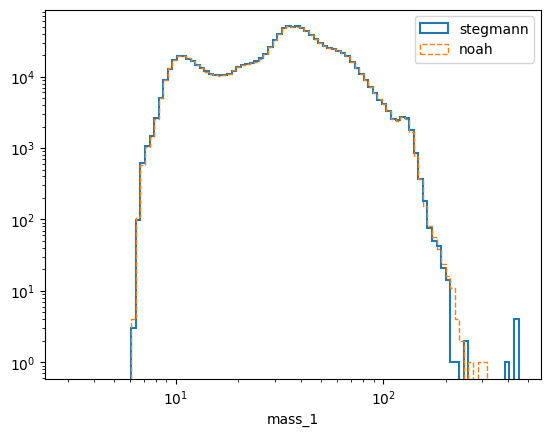

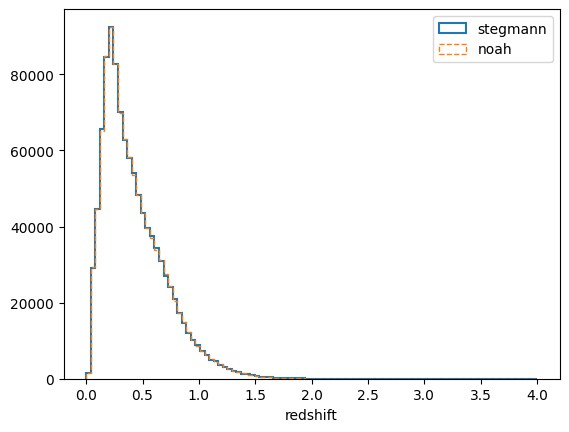

In [39]:
import numpy as np
from util import calc_chieff

posteriors_stegmann['chi_eff'] = calc_chieff(
    posteriors_stegmann['mass_ratio'],
    posteriors_stegmann['a_1'],
    posteriors_stegmann['a_2'],
    posteriors_stegmann['cos_tilt_1'],
    posteriors_stegmann['cos_tilt_2']
)

posteriors['chi_eff'] = calc_chieff(
    posteriors['mass_ratio'],
    posteriors['a_1'],
    posteriors['a_2'],
    posteriors['cos_tilt_1'],
    posteriors['cos_tilt_2']
)


bins = np.linspace(-1, 1, 50)

for key in['chi_eff', 'cos_tilt_1', 'cos_tilt_2', 'a_1', 'a_2', 'mass_ratio', 'mass_1', 'redshift']:
    if key in ['cos_tilt_1', 'cos_tilt_2', 'chi_eff']:
        bins = np.linspace(-1, 1, 50)
    elif key in ['a_1', 'a_2']:
        bins = np.linspace(0, 1, 50)
    elif key == 'mass_1':
        bins = np.logspace(np.log10(3), np.log10(450), 100) #np.linspace(0, 450, 100)
    elif key == 'redshift':
        bins = np.linspace(0, 4, 100)
    else:
        bins = 50

    fig, ax = plt.subplots()
    ax.hist(
        posteriors_stegmann[key].flatten(),
        histtype='step',
        bins=bins,
        label='stegmann',
        lw=1.5
    );

    ax.hist(
        posteriors[key].flatten(),
        histtype='step',
        bins=bins,
        label='noah',
        lw=1,
        linestyle='--'
    );
    ax.set_xlabel(key)

    if key == 'mass_1':
        ax.loglog()

    ax.legend();


In [30]:
with open(f'../../data/stegmann/gwtc4_injections_dict.pkl', 'rb') as f:
    injections_stegmann = pickle.load(f)

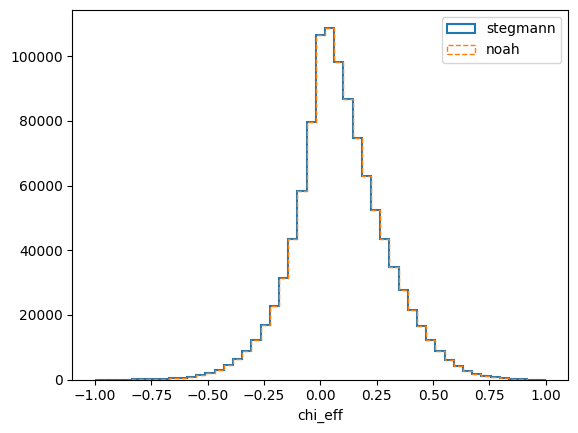

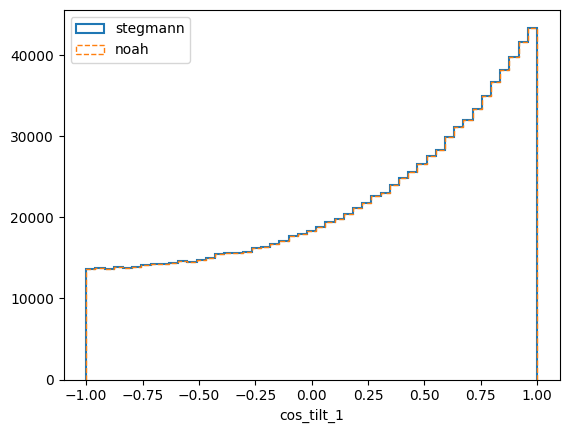

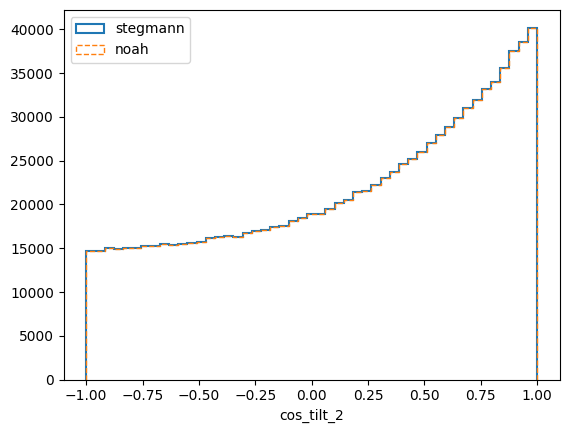

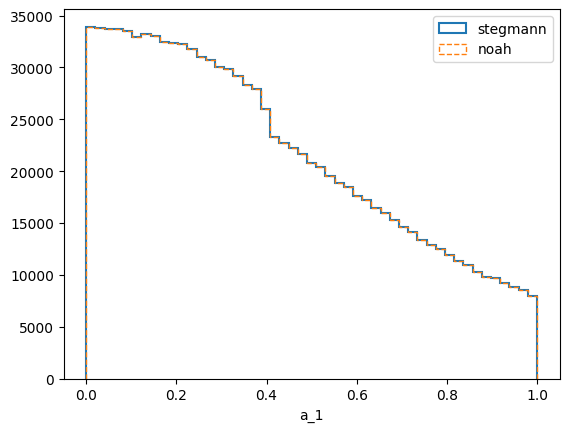

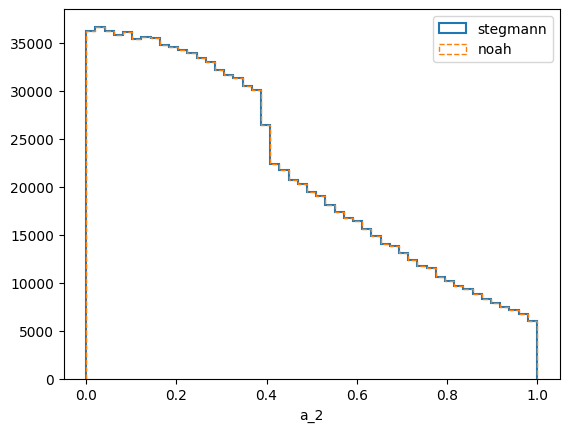

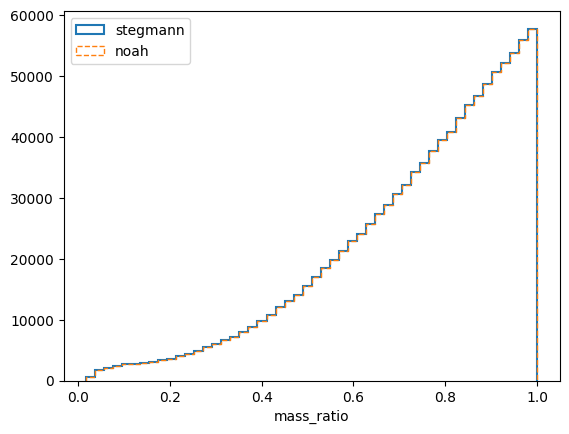

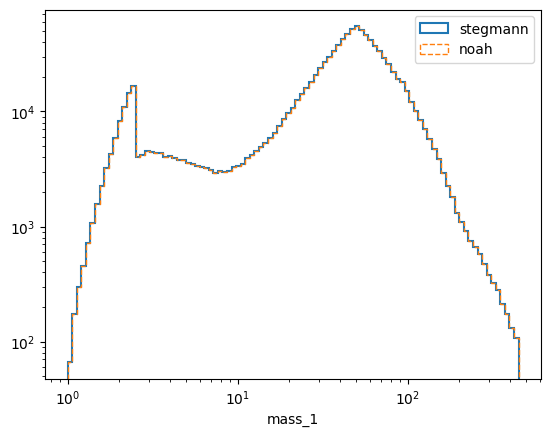

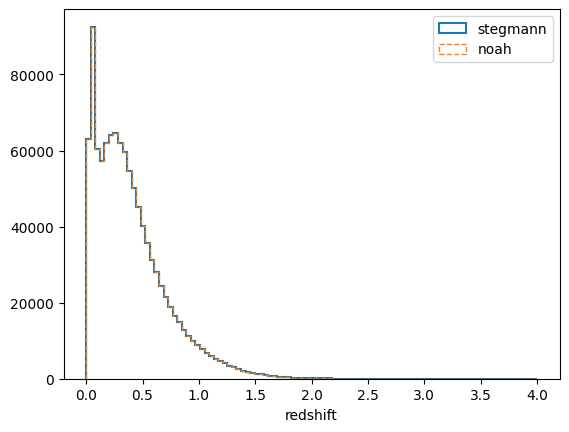

In [37]:
import numpy as np
from util import calc_chieff

injections_stegmann['chi_eff'] = calc_chieff(
    injections_stegmann['mass_ratio'],
    injections_stegmann['a_1'],
    injections_stegmann['a_2'],
    injections_stegmann['cos_tilt_1'],
    injections_stegmann['cos_tilt_2']
)

if 'chi_eff' not in injections:
    injections['chi_eff'] = calc_chieff(
        injections['mass_ratio'],
        injections['a_1'],
        injections['a_2'],
        injections['cos_tilt_1'],
        injections['cos_tilt_2']
    )


bins = np.linspace(-1, 1, 50)

for key in['chi_eff', 'cos_tilt_1', 'cos_tilt_2', 'a_1', 'a_2', 'mass_ratio', 'mass_1', 'redshift']:
    if key in ['cos_tilt_1', 'cos_tilt_2', 'chi_eff']:
        bins = np.linspace(-1, 1, 50)
    elif key in ['a_1', 'a_2']:
        bins = np.linspace(0, 1, 50)
    elif key == 'mass_1':
        bins = np.logspace(np.log10(1), np.log10(450), 100) #np.linspace(0, 450, 100)
    elif key == 'redshift':
        bins = np.linspace(0, 4, 100)
    else:
        bins = 50

    fig, ax = plt.subplots()
    ax.hist(
        injections_stegmann[key].flatten(),
        histtype='step',
        bins=bins,
        label='stegmann',
        lw=1.5
    );

    ax.hist(
        injections[key].flatten(),
        histtype='step',
        bins=bins,
        label='noah',
        lw=1,
        linestyle='--'
    );
    ax.set_xlabel(key)

    if key == 'mass_1':
        ax.loglog()

    ax.legend();


In [32]:
len(injections['chi_eff'])

1065922

In [34]:
injections_stegmann

{'mass_1': array([45.15422679, 20.46347243, 31.49269517, ..., 22.27432032,
        65.88646499,  2.25242744], shape=(1065922,)),
 'mass_ratio': array([0.44799082, 0.81033314, 0.74996786, ..., 0.73068224, 0.66393557,
        0.85476055], shape=(1065922,)),
 'a_1': array([0.16243093, 0.137373  , 0.02898515, ..., 0.99583277, 0.55638647,
        0.49881459], shape=(1065922,)),
 'a_2': array([0.3627992 , 0.28184632, 0.2437523 , ..., 0.95607815, 0.32076786,
        0.27731706], shape=(1065922,)),
 'cos_tilt_1': array([ 0.07403731,  0.72230954, -0.38512757, ...,  0.93889264,
         0.67981822, -0.2130991 ], shape=(1065922,)),
 'cos_tilt_2': array([ 0.71306297, -0.08572489,  0.94640479, ...,  0.88695208,
        -0.75479131, -0.3162247 ], shape=(1065922,)),
 'redshift': array([0.1502511 , 0.10812333, 0.183693  , ..., 0.38669392, 0.73260368,
        0.03056327], shape=(1065922,)),
 'prior': array([9.44182132e-05, 2.13199834e-04, 4.10222859e-04, ...,
        1.33253181e-05, 2.76813965e-05, 1.1